# Mouse vs Human Proximal-Tubule Pseudospace Comparison

This notebook compares healthy mouse control tubules against human tubules in the shared
one-to-one ortholog space created upstream. It focuses on proximal tubules because the
canonical S1-S3 markers and requested biological question concern proximal-to-distal PT
architecture.

The canonical saved DPT object contains the upstream-filtered ortholog expression matrix
and `total_scanpy_dpt`, but not a separately saved `pt_scanpy_dpt` or broad PT label.
The notebook attaches `broad_tubule_marker_call` from the lean root-level DPT file,
restricts to proximal tubules, and uses the upstream `total_scanpy_dpt` values directly
as the shared pseudospace axis. The harmonized DPT coordinate is already normalized to
`[0, 1]`; no species-specific reranking or realignment is applied.

Dynamic and species-pattern tests use tubule-level spline regressions. Equal-width
pseudospace bins are used only for descriptive segment-wise conservation summaries and
visualization; they are not used for GAM-like trajectory inference.


## Input data, cohort definition, and shared pseudospace

The cross-species comparison is performed using
`data/pseudspace_analysis/all_tubules_scanpy_dpt.h5ad`, the canonical Scanpy diffusion
pseudotime (DPT) output generated upstream. This object contains 45,753 tubules and
9,610 one-to-one ortholog genes retained after the upstream expression-count filter. The
analysis uses `layers["lognorm"]`, which contains library-size-normalized and
log-transformed expression values. Genes removed by the upstream filter are not
reintroduced.

The canonical DPT output contains `total_scanpy_dpt`, but it does not contain
`broad_tubule_marker_call`. Proximal-tubule labels are therefore joined by tubule
identifier from the lean root-level file `data/all_tubules_scanpy_dpt.h5ad`. This second
file is used only to attach `broad_tubule_marker_call`; expression values and DPT values
are read directly from the canonical filtered DPT object.

The analysis is restricted to tubules with `broad_tubule_marker_call == "PT"`. Mouse
tubules are further restricted to `condition == "Control"` so that ischemia-reperfusion
injury is not confounded with species. Human tubules are retained from the available
human samples. The comparison therefore evaluates healthy mouse controls against human
proximal tubules.

The saved object does not contain a separately reconstructed PT-only DPT coordinate.
The harmonized `total_scanpy_dpt` coordinate is already normalized to `[0, 1]` upstream
and is used directly:

`shared pseudospace = total_scanpy_dpt`.

No within-species percentile reranking, rescaling, or realignment is performed. Mouse
and human PT tubules are modeled at their original positions on the same harmonized DPT
axis. Tubule-level values on this shared coordinate are used directly for trajectory
modeling.


In [2]:
from pathlib import Path
import json
import os
import warnings

CACHE_ROOT = Path('/tmp/mouse_vs_human_pseudospace_cache')
CACHE_ROOT.mkdir(exist_ok=True)
(CACHE_ROOT / 'matplotlib').mkdir(exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(CACHE_ROOT / 'matplotlib'))
os.environ.setdefault('XDG_CACHE_HOME', str(CACHE_ROOT))

import numpy as np
import pandas as pd
import anndata as ad
import scipy.sparse as sp
from scipy.ndimage import gaussian_filter1d
from scipy.stats import f as f_dist, spearmanr
from patsy import dmatrix
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import Image, display

warnings.filterwarnings('ignore', category=FutureWarning)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.dpi'] = 180

PROJECT_DIR = Path.cwd().resolve()
INPUT_PATH = PROJECT_DIR / 'data' / 'pseudspace_analysis' / 'all_tubules_scanpy_dpt.h5ad'
PT_LABEL_PATH = PROJECT_DIR / 'data' / 'all_tubules_scanpy_dpt.h5ad'
OUTPUT_DIR = PROJECT_DIR / 'data' / 'mouse_vs_human'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CONFIG = {
    'pseudotime_col': 'total_scanpy_dpt',
    'n_bins': 30,
    'spline_df': 6,
    'grid_points': 101,
    'min_detected_fraction': 0.03,
    'min_mean_expression': 0.01,
    'dynamic_permutations': 200,
    'permutation_seed': 7,
    'dynamic_fdr': 0.05,
    'interaction_fdr': 0.05,
    'min_dynamic_amplitude': 0.10,
    'conserved_curve_correlation': 0.70,
    'peak_shift_threshold': 0.15,
    'amplitude_ratio_threshold': 1.50,
    'heatmap_genes': 60,
    'pathway_min_genes': 10,
    'pathway_max_genes': 150,
    'pathway_top_plot': 12,
    'enrichment_fdr': 0.05,
    'enrichment_min_overlap': 5,
    'enrichment_priority_classes': [
        'conserved_dynamic_genes',
        'species_divergent_genes',
        'mouse_specific_gradients',
        'human_specific_gradients',
    ],
}

adata = ad.read_h5ad(INPUT_PATH)
pt_labels = ad.read_h5ad(PT_LABEL_PATH)
if 'lognorm' not in adata.layers:
    raise KeyError(f'{INPUT_PATH.name} is missing required lognorm layer')
missing_label_obs = sorted(set(adata.obs_names) - set(pt_labels.obs_names))
if missing_label_obs:
    raise KeyError(f'{len(missing_label_obs)} tubules are missing from {PT_LABEL_PATH.name}')
adata.obs['broad_tubule_marker_call'] = pt_labels.obs.loc[
    adata.obs_names, 'broad_tubule_marker_call'
].to_numpy()
required_obs = {'species', 'condition', 'broad_tubule_marker_call', CONFIG['pseudotime_col']}
missing_obs = sorted(required_obs - set(adata.obs.columns))
if missing_obs:
    raise KeyError(f'Joined AnnData is missing required obs columns: {missing_obs}')

obs = adata.obs
pt_mask = obs['broad_tubule_marker_call'].astype(str).eq('PT').to_numpy()
healthy_mouse = (
    obs['species'].astype(str).str.lower().eq('mouse')
    & obs['condition'].astype(str).str.lower().eq('control')
).to_numpy()
human = obs['species'].astype(str).str.lower().eq('human').to_numpy()
keep = pt_mask & (healthy_mouse | human)
adata_pt = adata[keep].copy()
adata_pt.obs['comparison_species'] = np.where(
    adata_pt.obs['species'].astype(str).str.lower().eq('mouse'), 'mouse', 'human'
)
adata_pt.obs['shared_pseudospace'] = adata_pt.obs[CONFIG['pseudotime_col']].to_numpy(dtype=float)
if not adata_pt.obs['shared_pseudospace'].between(0, 1, inclusive='both').all():
    raise ValueError(f"{CONFIG['pseudotime_col']} must already be normalized to [0, 1]")

cohort_summary = (
    adata_pt.obs.groupby(['comparison_species', 'sample'], observed=True)
    .size().rename('n_pt_tubules').reset_index()
)
cohort_summary.to_csv(OUTPUT_DIR / 'cohort_summary.csv', index=False)
print(f'Loaded canonical filtered DPT object: {INPUT_PATH.relative_to(PROJECT_DIR)}')
print(f'Filtered matrix: {adata.n_obs:,} tubules x {adata.n_vars:,} ortholog genes')
print(f'Attached PT labels from: {PT_LABEL_PATH.relative_to(PROJECT_DIR)}')
print(f'Healthy PT comparison cohort: {adata_pt.n_obs:,} tubules')
print(cohort_summary.to_string(index=False))


Loaded canonical filtered DPT object: data/pseudspace_analysis/all_tubules_scanpy_dpt.h5ad
Filtered matrix: 45,753 tubules x 9,610 ortholog genes
Attached PT labels from: data/all_tubules_scanpy_dpt.h5ad
Healthy PT comparison cohort: 11,511 tubules
comparison_species    sample  n_pt_tubules
             human HUK1_COR1          3034
             human HUK1_MED1          3327
             mouse   Ctrl1A2          2503
             mouse   Ctrl1A4          2647


## Tubule-level spline-model implementation

Expression trajectories are modeled at tubule resolution using a GAM-like spline
regression framework. Each proximal tubule contributes its own log-normalized expression
measurement and shared pseudospace value to the regression. Expression is not
averaged into pseudospace bins before dynamic-gene or species-interaction testing.

Smooth trajectories are represented by cubic B-splines with `6` basis functions.
Three internal knots are fixed at the pooled PT pseudospace quartiles so that mouse,
human, interaction-model, and prediction design matrices use the same spline basis.
Models use the upstream shared `[0, 1]` DPT coordinate without reranking. Fitted curves
are evaluated on a `101`-point grid restricted to the observed PT pseudospace range
shared by both species, avoiding extrapolation outside cross-species PT support. The
models are fitted with ordinary least squares using sparse matrix cross-products, which
permits all tested orthologs to be evaluated simultaneously without converting the
tubule-by-gene matrix into a dense matrix.

Before trajectory testing, genes must be detected in at least `3%` of the combined
mouse-human PT cohort and must have mean log-normalized expression of at least `0.01`.
These thresholds are applied after the upstream 9,610-gene filter and define the tested
ortholog set for the comparison.

For species-specific dynamic-gene detection, the observed nested-model F statistic is
compared with an empirical permutation null. Shared pseudospace values are shuffled
among tubules within each species `200` times using random seed `7`, preserving the
expression matrix and the species-specific pseudospace distribution while breaking the
expression-pseudospace association. The empirical P value is calculated as
`(1 + number of permuted F statistics >= observed F) / (1 + 200)`. Parametric F-test
P values are retained in the output for reference, but dynamic-gene calls use the
Benjamini-Hochberg-adjusted empirical permutation P values.

The pooled species-by-spline interaction model is compared using its parametric F-test,
with Benjamini-Hochberg correction across genes. Spearman correlations are used for
cross-species trajectory-shape comparisons. Constant curves are retained as undefined
correlations (`NaN`) rather than assigned artificial agreement.

Tubules are treated as observational units in these spline models. The resulting P
values quantify tubule-level trajectory evidence and should not be interpreted as
donor-level replication because the available dataset contains limited biological
replication.


In [3]:
def as_csr(matrix):
    if sp.issparse(matrix):
        return matrix.tocsr().astype(np.float64)
    return sp.csr_matrix(np.asarray(matrix, dtype=np.float64))


def zscore_rows(values):
    values = np.asarray(values, dtype=float)
    mean = np.nanmean(values, axis=1, keepdims=True)
    std = np.nanstd(values, axis=1, keepdims=True)
    std[~np.isfinite(std) | (std == 0)] = 1.0
    return (values - mean) / std


def make_design(x, knots):
    spline = np.asarray(
        dmatrix(
            'bs(x, knots=knots, degree=3, include_intercept=False, '
            'lower_bound=0, upper_bound=1) - 1',
            {'x': np.asarray(x, dtype=float), 'knots': np.asarray(knots, dtype=float)},
        )
    )
    return np.column_stack([np.ones(len(x)), spline])


def make_bins(pseudospace, n_bins=CONFIG['n_bins']):
    values = np.asarray(pseudospace, dtype=float)
    ids = np.floor(np.clip(values, 0, 1 - np.finfo(float).eps) * n_bins).astype(int)
    centers = (np.arange(n_bins) + 0.5) / n_bins
    return ids, centers


def binned_means(matrix, pseudospace, n_bins=CONFIG['n_bins']):
    ids, centers = make_bins(pseudospace, n_bins=n_bins)
    one_hot = sp.csr_matrix(
        (np.ones(ids.size), (np.arange(ids.size), ids)), shape=(ids.size, n_bins)
    )
    counts = np.asarray(one_hot.sum(axis=0)).ravel()
    sums = matrix.T @ one_hot
    if sp.issparse(sums):
        sums = sums.toarray()
    means = np.asarray(sums) / np.maximum(counts, 1)[None, :]
    means[:, counts == 0] = np.nan
    return means, counts, centers


def sparse_ols_sse(matrix, design):
    # Fit all genes together through sparse cross-products: matrix is tubules x genes.
    values = as_csr(matrix)
    x = np.asarray(design, dtype=float)
    xty = np.asarray(x.T @ values)
    beta = np.linalg.pinv(x) @ values
    beta = np.asarray(beta)
    yty = np.asarray(values.multiply(values).sum(axis=0)).ravel()
    sse = yty - np.sum(beta * xty, axis=0)
    return np.maximum(sse, 0.0), beta


def sparse_nested_f_test(matrix, reduced_design, full_design):
    sse_reduced, _ = sparse_ols_sse(matrix, reduced_design)
    sse_full, beta_full = sparse_ols_sse(matrix, full_design)
    n = matrix.shape[0]
    df_num = full_design.shape[1] - reduced_design.shape[1]
    df_den = max(n - full_design.shape[1], 1)
    numerator = np.maximum(sse_reduced - sse_full, 0) / max(df_num, 1)
    denominator = np.maximum(sse_full / df_den, 1e-12)
    f_stat = numerator / denominator
    pvalue = f_dist.sf(f_stat, df_num, df_den)
    return f_stat, pvalue, beta_full

def empirical_dynamic_pvalues(matrix, pseudospace, knots, observed_f, n_permutations, rng):
    null = np.ones((pseudospace.size, 1))
    sse_null, _ = sparse_ols_sse(matrix, null)
    exceedances = np.zeros(matrix.shape[1], dtype=np.int32)
    for _ in range(n_permutations):
        shuffled = rng.permutation(pseudospace)
        permuted_design = make_design(shuffled, knots)
        sse_full, _ = sparse_ols_sse(matrix, permuted_design)
        df_num = permuted_design.shape[1] - null.shape[1]
        df_den = max(matrix.shape[0] - permuted_design.shape[1], 1)
        numerator = np.maximum(sse_null - sse_full, 0) / max(df_num, 1)
        denominator = np.maximum(sse_full / df_den, 1e-12)
        permuted_f = numerator / denominator
        exceedances += permuted_f >= observed_f
    return (exceedances + 1) / (n_permutations + 1)


def bh_adjust(pvalues):
    pvalues = np.asarray(pvalues, dtype=float)
    adjusted = np.ones_like(pvalues)
    valid = np.isfinite(pvalues)
    adjusted[valid] = multipletests(pvalues[valid], method='fdr_bh')[1]
    return adjusted


def safe_spearman(left, right):
    left = np.asarray(left, dtype=float)
    right = np.asarray(right, dtype=float)
    valid = np.isfinite(left) & np.isfinite(right)
    if valid.sum() < 3 or np.ptp(left[valid]) == 0 or np.ptp(right[valid]) == 0:
        return np.nan
    return spearmanr(left[valid], right[valid]).correlation


def fit_species_curves(adata_obj):
    matrix = as_csr(adata_obj.layers['lognorm'])
    detected = np.asarray((matrix > 0).sum(axis=0)).ravel()
    means = np.asarray(matrix.mean(axis=0)).ravel()
    min_detected = int(np.ceil(CONFIG['min_detected_fraction'] * adata_obj.n_obs))
    test_mask = (detected >= min_detected) & (means >= CONFIG['min_mean_expression'])
    genes = adata_obj.var_names.to_numpy()[test_mask]
    matrix = matrix[:, test_mask]
    pooled_pseudospace = adata_obj.obs['shared_pseudospace'].to_numpy(dtype=float)
    spline_knots = np.quantile(pooled_pseudospace, [0.25, 0.50, 0.75])
    species_support = [
        adata_obj.obs.loc[adata_obj.obs['comparison_species'].eq(species), 'shared_pseudospace']
        .to_numpy(dtype=float)
        for species in ['mouse', 'human']
    ]
    overlap_min = max(np.min(values) for values in species_support)
    overlap_max = min(np.max(values) for values in species_support)
    grid = np.linspace(overlap_min, overlap_max, CONFIG['grid_points'])
    grid_design = make_design(grid, spline_knots)
    species_results = {}
    rng = np.random.default_rng(CONFIG['permutation_seed'])
    for species in ['mouse', 'human']:
        subset = adata_obj.obs['comparison_species'].eq(species).to_numpy()
        pseudospace = adata_obj.obs.loc[subset, 'shared_pseudospace'].to_numpy(dtype=float)
        species_matrix = matrix[subset]
        design = make_design(pseudospace, spline_knots)
        null = np.ones((pseudospace.size, 1))
        f_stat, parametric_pvalue, beta = sparse_nested_f_test(species_matrix, null, design)
        permutation_pvalue = empirical_dynamic_pvalues(
            species_matrix,
            pseudospace,
            spline_knots,
            f_stat,
            CONFIG['dynamic_permutations'],
            rng,
        )
        curves = (grid_design @ beta).T
        amplitude = np.ptp(curves, axis=1)
        permutation_padj = bh_adjust(permutation_pvalue)
        dynamic = (
            (permutation_padj < CONFIG['dynamic_fdr'])
            & (amplitude >= CONFIG['min_dynamic_amplitude'])
        )
        means_by_bin, counts, centers = binned_means(species_matrix, pseudospace)
        species_results[species] = {
            'binned_means': means_by_bin,
            'counts': counts,
            'centers': centers,
            'curves': curves,
            'f_stat': f_stat,
            'parametric_pvalue': parametric_pvalue,
            'parametric_padj': bh_adjust(parametric_pvalue),
            'permutation_pvalue': permutation_pvalue,
            'permutation_padj': permutation_padj,
            'padj': permutation_padj,
            'amplitude': amplitude,
            'dynamic': dynamic,
        }
    return genes, matrix, grid, species_results

def fit_species_interaction(adata_obj, matrix, genes):
    pseudospace = adata_obj.obs['shared_pseudospace'].to_numpy(dtype=float)
    spline_knots = np.quantile(pseudospace, [0.25, 0.50, 0.75])
    species = adata_obj.obs['comparison_species'].eq('human').to_numpy(dtype=float)
    spline = make_design(pseudospace, spline_knots)[:, 1:]
    reduced = np.column_stack([np.ones(pseudospace.size), species, spline])
    full = np.column_stack([reduced, spline * species[:, None]])
    f_stat, pvalue, _ = sparse_nested_f_test(matrix, reduced, full)
    return pd.DataFrame({
        'gene': genes,
        'interaction_f_stat': f_stat,
        'interaction_pvalue': pvalue,
        'interaction_padj': bh_adjust(pvalue),
    })

def rowwise_curve_correlation(left, right):
    values = []
    for a, b in zip(left, right):
        corr = safe_spearman(a, b)
        values.append(corr)
    return np.asarray(values)


def resolve_present(requested, universe):
    lookup = {gene.upper(): gene for gene in universe}
    return [lookup[gene.upper()] for gene in requested if gene.upper() in lookup]


## Tubule-level dynamic ortholog detection and species-divergent trajectory testing

For each tested one-to-one ortholog, dynamic expression is assessed separately in mouse
and human PT tubules. Each row of the regression design matrix represents one tubule.
The null model contains an intercept only:

`expression ~ 1`

The full species-specific trajectory model contains the cubic spline basis:

`expression ~ spline(shared pseudospace, df = 6)`

A permutation null is used for species-specific dynamic-gene detection. Within each
species, shared pseudospace values are shuffled among tubules `200` times using seed `7`.
For each shuffle, the spline model is refitted and its F statistic is recorded. The
empirical dynamic-gene P value is
`(1 + number of permuted F statistics >= observed F) / (1 + 200)`, followed by
Benjamini-Hochberg adjustment across tested genes. A gene is classified as dynamic
within a species when empirical permutation FDR `< 0.05` and the fitted trajectory
amplitude (`maximum - minimum`) is at least `0.10` log-normalized expression units.
Parametric spline-model P values are retained in the exported table for reference.
Amplitude and peak-position metrics are calculated over the observed PT pseudospace
range shared by both species, not over unsupported extrapolated positions.

Species-divergent trajectory shapes are tested using all mouse and human PT tubules. The
reduced model allows a species-level intercept shift and a shared smooth trajectory:

`expression ~ species + spline(shared pseudospace, df = 6)`

The full model additionally allows species-specific smooth deviations:

`expression ~ species + spline(shared pseudospace, df = 6) + species:spline(shared pseudospace, df = 6)`

The interaction F-test identifies genes whose pseudospace-dependent expression patterns
differ between species after accounting for an overall species-level expression shift.
Species-pattern hits are defined using Benjamini-Hochberg-adjusted `P < 0.05`.

For every tested ortholog, the analysis records mouse and human dynamic-test FDR values,
fitted amplitudes, Spearman curve correlation, fitted peak positions, peak-position
shift (`human peak - mouse peak`), and the species-by-spline interaction statistics.
Orthologs are assigned to one mutually exclusive interpretive class using the following
rules in order:

1. `mouse-specific gradient`: dynamic in mouse only.
2. `human-specific gradient`: dynamic in human only.
3. `not dynamic in either`: dynamic in neither species.
4. `divergent/reversed gradient`: dynamic in both species with curve correlation `< 0`.
5. `peak-shifted`: dynamic in both species with absolute peak shift `>= 0.15`.
6. `conserved shape, amplitude-shifted`: dynamic in both species with amplitude ratio `>= 1.5`.
7. `conserved dynamic`: dynamic in both species with curve correlation `>= 0.70`.
8. `undefined curve correlation`: genes dynamic in both species with an undefined curve correlation.
9. `divergent shape`: remaining genes dynamic in both species.

The full ortholog-level table and the significant interaction subset are written to
`ortholog_trajectory_classification.csv` and
`species_pattern_interaction_hits.csv`, respectively.


In [4]:
genes, test_matrix, grid, species_results = fit_species_curves(adata_pt)
interaction = fit_species_interaction(adata_pt, test_matrix, genes)
mouse = species_results['mouse']
human = species_results['human']

curve_corr = rowwise_curve_correlation(mouse['curves'], human['curves'])
mouse_peak = grid[np.argmax(mouse['curves'], axis=1)]
human_peak = grid[np.argmax(human['curves'], axis=1)]
peak_shift = human_peak - mouse_peak
amplitude_diff = human['amplitude'] - mouse['amplitude']
amplitude_ratio = np.maximum(mouse['amplitude'], human['amplitude']) / np.maximum(
    np.minimum(mouse['amplitude'], human['amplitude']), 1e-6
)

ortholog_stats = pd.DataFrame({
    'gene': genes,
    'mouse_dynamic_permutation_pvalue': mouse['permutation_pvalue'],
    'mouse_dynamic_permutation_padj': mouse['permutation_padj'],
    'mouse_dynamic_parametric_pvalue': mouse['parametric_pvalue'],
    'mouse_dynamic_parametric_padj': mouse['parametric_padj'],
    'human_dynamic_permutation_pvalue': human['permutation_pvalue'],
    'human_dynamic_permutation_padj': human['permutation_padj'],
    'human_dynamic_parametric_pvalue': human['parametric_pvalue'],
    'human_dynamic_parametric_padj': human['parametric_padj'],
    'mouse_dynamic': mouse['dynamic'],
    'human_dynamic': human['dynamic'],
    'mouse_amplitude': mouse['amplitude'],
    'human_amplitude': human['amplitude'],
    'amplitude_difference_human_minus_mouse': amplitude_diff,
    'amplitude_ratio': amplitude_ratio,
    'curve_spearman': curve_corr,
    'mouse_peak_pseudospace': mouse_peak,
    'human_peak_pseudospace': human_peak,
    'peak_shift_human_minus_mouse': peak_shift,
}).merge(interaction, on='gene', how='left')


def classify(row):
    mouse_dynamic = bool(row['mouse_dynamic'])
    human_dynamic = bool(row['human_dynamic'])
    if mouse_dynamic and not human_dynamic:
        return 'mouse-specific gradient'
    if human_dynamic and not mouse_dynamic:
        return 'human-specific gradient'
    if not mouse_dynamic and not human_dynamic:
        return 'not dynamic in either'
    if not np.isfinite(row['curve_spearman']):
        return 'undefined curve correlation'
    if row['curve_spearman'] < 0:
        return 'divergent/reversed gradient'
    if abs(row['peak_shift_human_minus_mouse']) >= CONFIG['peak_shift_threshold']:
        return 'peak-shifted'
    if row['amplitude_ratio'] >= CONFIG['amplitude_ratio_threshold']:
        return 'conserved shape, amplitude-shifted'
    if row['curve_spearman'] >= CONFIG['conserved_curve_correlation']:
        return 'conserved dynamic'
    return 'divergent shape'


ortholog_stats['conservation_class'] = ortholog_stats.apply(classify, axis=1)
ortholog_stats['significant_species_pattern'] = (
    ortholog_stats['interaction_padj'] < CONFIG['interaction_fdr']
)
ortholog_stats = ortholog_stats.sort_values(
    ['significant_species_pattern', 'interaction_padj', 'curve_spearman'],
    ascending=[False, True, False],
)
ortholog_stats.to_csv(OUTPUT_DIR / 'ortholog_trajectory_classification.csv', index=False)
interaction_hits = ortholog_stats.loc[ortholog_stats['significant_species_pattern']].copy()
interaction_hits.to_csv(OUTPUT_DIR / 'species_pattern_interaction_hits.csv', index=False)

classification_summary = (
    ortholog_stats['conservation_class'].value_counts().rename_axis('conservation_class')
    .rename('n_orthologs').reset_index()
)
classification_summary.to_csv(OUTPUT_DIR / 'ortholog_classification_summary.csv', index=False)

print(f'Tested {len(genes):,} expressed one-to-one orthologs')
print(f"Dynamic in mouse: {int(mouse['dynamic'].sum()):,}")
print(f"Dynamic in human: {int(human['dynamic'].sum()):,}")
print(f"Dynamic in both: {int((mouse['dynamic'] & human['dynamic']).sum()):,}")
print(f"Significant species-by-spline patterns: {len(interaction_hits):,}")
print('\nOrtholog trajectory classes:')
print(classification_summary.to_string(index=False))


Tested 9,543 expressed one-to-one orthologs
Dynamic in mouse: 4,617
Dynamic in human: 5,158
Dynamic in both: 2,973
Significant species-by-spline patterns: 6,360

Ortholog trajectory classes:
                conservation_class  n_orthologs
             not dynamic in either         2741
           human-specific gradient         2185
           mouse-specific gradient         1644
       divergent/reversed gradient         1237
conserved shape, amplitude-shifted          705
                      peak-shifted          516
                   divergent shape          309
                 conserved dynamic          206


## Canonical marker-gradient validation and pathway-module comparison

The shared pseudospace coordinate is first validated using canonical proximal-tubule marker
genes. S1 is represented by `Slc5a2`; S2 by `Slc22a6`, `Slc34a1`, and `Gatm`; and S3 by
`Slc7a13` and `Acsm3`. For each available marker, the previously fitted species-specific
spline trajectory is exported and plotted across shared pseudospace. Marker genes
that are absent after filtering are omitted rather than restored from an unfiltered
matrix.

To compare functional programs, predefined pathway modules are evaluated using only
genes available in the filtered tested-ortholog set. The modules cover sodium transport,
organic anion transport, glucose transport, amino acid transport, fatty-acid oxidation,
oxidative phosphorylation, acid-base regulation, epithelial polarity and junctions, and
injury or stress susceptibility. The complete gene lists are declared in the code cell
below and are exported with the results.

For each available module gene, its fitted trajectory is standardized within species to
a z-score across the `101` pseudospace-grid positions. A module trajectory is the mean
of these standardized gene curves. Mouse-human module conservation is summarized using
Spearman correlation, fitted peak positions, peak-position shift
(`human peak - mouse peak`), and the trapezoidal area under the human-minus-mouse
trajectory-difference curve. Modules with no retained genes are omitted. The fitted
module curves and summary statistics are written to `pathway_module_curves.csv` and
`pathway_module_summary.csv`.


Per-sample sensitivity plots are also generated for every retained canonical marker and
every pathway module. Each available sample is modeled separately at tubule resolution
using the same pooled spline knots and the same shared-support prediction grid used for
the species-level comparison. Each displayed sample curve is masked outside that
sample's observed pseudospace support to avoid interpreting extrapolated tails. For
modules, sample-specific gene curves are z-scored across the prediction grid before
averaging. These plots expose sample-level heterogeneity and help identify trajectories
driven by a single sample.


In [5]:
MARKER_GROUPS = {
    'S1': ['Slc5a2'],
    'S2': ['Slc22a6', 'Slc34a1', 'Gatm'],
    'S3': ['Slc7a13', 'Acsm3'],
}
PATHWAY_MODULES = {
    'sodium transport': ['Slc34a1', 'Slc9a3', 'Atp1a1', 'Atp1b1'],
    'organic anion transport': ['Slc22a6', 'Slc22a8', 'Slc22a7', 'Slco4c1', 'Abcc2', 'Abcc4'],
    'glucose transport': ['Slc5a2', 'Slc5a1', 'Slc2a2'],
    'amino acid transport': ['Slc7a13', 'Slc6a19', 'Slc3a1', 'Slc7a9', 'Slc36a2'],
    'fatty acid oxidation': ['Cpt1a', 'Acox1', 'Acadm', 'Acadl', 'Hadh', 'Acaa2'],
    'oxidative phosphorylation': ['Ndufa1', 'Ndufa2', 'Ndufb3', 'Cox4i1', 'Cox5a', 'Atp5f1a'],
    'acid-base regulation': ['Slc4a4', 'Slc9a3', 'Car2', 'Car4', 'Atp6v1b1'],
    'epithelial polarity / junctions': ['Cldn2', 'Cldn10', 'Cldn16', 'Tjp1', 'Cdh1'],
    'injury / stress susceptibility': ['Havcr1', 'Lcn2', 'Vcam1', 'Spp1', 'Krt8', 'Krt18'],
}

gene_index = {gene: i for i, gene in enumerate(genes)}
marker_rows = []
for group, requested in MARKER_GROUPS.items():
    for gene in resolve_present(requested, genes):
        idx = gene_index[gene]
        for species, result in species_results.items():
            for x, value in zip(grid, result['curves'][idx]):
                marker_rows.append({
                    'marker_group': group, 'gene': gene, 'species': species,
                    'pseudospace': x, 'fitted_expression': value,
                })
marker_curves = pd.DataFrame(marker_rows)
marker_curves.to_csv(OUTPUT_DIR / 'canonical_marker_curves.csv', index=False)

module_rows = []
module_summary_rows = []
for module, requested in PATHWAY_MODULES.items():
    present = resolve_present(requested, genes)
    if not present:
        continue
    indices = [gene_index[gene] for gene in present]
    species_module_curves = {}
    for species, result in species_results.items():
        curves = zscore_rows(result['curves'][indices])
        module_curve = np.nanmean(curves, axis=0)
        species_module_curves[species] = module_curve
        for x, value in zip(grid, module_curve):
            module_rows.append({
                'module': module, 'species': species, 'pseudospace': x,
                'module_zscore': value, 'genes_present': ';'.join(present),
            })
    corr = safe_spearman(species_module_curves['mouse'], species_module_curves['human'])
    module_summary_rows.append({
        'module': module,
        'genes_present': ';'.join(present),
        'n_genes_present': len(present),
        'curve_spearman': corr,
        'mouse_peak_pseudospace': grid[np.argmax(species_module_curves['mouse'])],
        'human_peak_pseudospace': grid[np.argmax(species_module_curves['human'])],
        'peak_shift_human_minus_mouse': (
            grid[np.argmax(species_module_curves['human'])]
            - grid[np.argmax(species_module_curves['mouse'])]
        ),
        'auc_difference_human_minus_mouse': np.trapezoid(
            species_module_curves['human'] - species_module_curves['mouse'], grid
        ),
    })
module_curves = pd.DataFrame(module_rows)
module_summary = pd.DataFrame(module_summary_rows).sort_values('curve_spearman')
module_curves.to_csv(OUTPUT_DIR / 'pathway_module_curves.csv', index=False)
module_summary.to_csv(OUTPUT_DIR / 'pathway_module_summary.csv', index=False)
print('Pathway-module comparison:')
print(module_summary.to_string(index=False))


# Fit sample-specific curves for every retained marker and pathway-module gene.
sample_curve_genes = resolve_present(
    sorted({gene for requested in list(MARKER_GROUPS.values()) + list(PATHWAY_MODULES.values())
            for gene in requested}),
    genes,
)
sample_curve_indices = [gene_index[gene] for gene in sample_curve_genes]
sample_curve_index = {gene: i for i, gene in enumerate(sample_curve_genes)}
sample_knots = np.quantile(adata_pt.obs['shared_pseudospace'].to_numpy(dtype=float), [0.25, 0.50, 0.75])
sample_grid_design = make_design(grid, sample_knots)
sample_gene_curves = {}
sample_species = {}
for sample in adata_pt.obs['sample'].astype(str).unique():
    sample_mask = adata_pt.obs['sample'].astype(str).eq(sample).to_numpy()
    sample_pseudospace = adata_pt.obs.loc[sample_mask, 'shared_pseudospace'].to_numpy(dtype=float)
    sample_design = make_design(sample_pseudospace, sample_knots)
    _, sample_beta = sparse_ols_sse(test_matrix[sample_mask][:, sample_curve_indices], sample_design)
    fitted_sample_curves = (sample_grid_design @ sample_beta).T
    supported = (grid >= np.min(sample_pseudospace)) & (grid <= np.max(sample_pseudospace))
    fitted_sample_curves[:, ~supported] = np.nan
    sample_gene_curves[sample] = fitted_sample_curves
    sample_species[sample] = adata_pt.obs.loc[sample_mask, 'comparison_species'].astype(str).iloc[0]

sample_marker_rows = []
for group, requested in MARKER_GROUPS.items():
    for gene in resolve_present(requested, sample_curve_genes):
        gene_i = sample_curve_index[gene]
        for sample, curves in sample_gene_curves.items():
            for x, value in zip(grid, curves[gene_i]):
                sample_marker_rows.append({
                    'marker_group': group, 'gene': gene, 'sample': sample,
                    'species': sample_species[sample], 'pseudospace': x,
                    'fitted_expression': value,
                })
sample_marker_curves = pd.DataFrame(sample_marker_rows)
sample_marker_curves.to_csv(OUTPUT_DIR / 'per_sample_marker_curves.csv', index=False)

sample_module_rows = []
for module, requested in PATHWAY_MODULES.items():
    present = resolve_present(requested, sample_curve_genes)
    if not present:
        continue
    indices = [sample_curve_index[gene] for gene in present]
    for sample, curves in sample_gene_curves.items():
        standardized = zscore_rows(curves[indices])
        finite_counts = np.sum(np.isfinite(standardized), axis=0)
        module_curve = np.divide(
            np.nansum(standardized, axis=0),
            finite_counts,
            out=np.full(grid.size, np.nan),
            where=finite_counts > 0,
        )
        for x, value in zip(grid, module_curve):
            sample_module_rows.append({
                'module': module, 'sample': sample, 'species': sample_species[sample],
                'pseudospace': x, 'module_zscore': value,
                'genes_present': ';'.join(present),
            })
sample_module_curves = pd.DataFrame(sample_module_rows)
sample_module_curves.to_csv(OUTPUT_DIR / 'per_sample_module_curves.csv', index=False)


Pathway-module comparison:
                         module                               genes_present  n_genes_present  curve_spearman  mouse_peak_pseudospace  human_peak_pseudospace  peak_shift_human_minus_mouse  auc_difference_human_minus_mouse
      oxidative phosphorylation                 Ndufa1;Ndufa2;Ndufb3;Cox4i1                4       -0.593302                0.613097                0.018393                     -0.594704                          0.005892
           amino acid transport       Slc7a13;Slc6a19;Slc3a1;Slc7a9;Slc36a2                5       -0.278241                0.343334                0.091965                     -0.251370                          0.000010
 injury / stress susceptibility                       Vcam1;Spp1;Krt8;Krt18                4       -0.147991                0.613097                0.110357                     -0.502739                          0.007516
        organic anion transport Slc22a6;Slc22a8;Slc22a7;Slco4c1;Abcc2;Abcc4              

## Functional enrichment-guided pathway trajectory analysis

Pathway-level trajectory modeling is downstream of the ortholog-level spline results. The
analysis first defines biologically interpretable gene lists from the gene-level dynamic
and species-pattern tests: mouse dynamic genes, human dynamic genes, conserved dynamic
genes, species-divergent genes, mouse-specific gradients, human-specific gradients, and
peak-shifted genes.

Each gene list is tested for overrepresentation against locally cached functional gene-set
libraries: `GO_Biological_Process_2023`, `Reactome_2022`, `MSigDB_Hallmark_2020`, and the
available mouse-specific KEGG collection `KEGG_2019_Mouse`. Curated kidney and
proximal-tubule gene sets are added as a separate `Kidney_PT_Custom` collection. The
background universe is the set of all tested orthologs from the expression and ortholog
filters used for the spline tests, not the whole genome.

Each term is intersected with this tested-ortholog background before enrichment. Terms are
eligible when they contain between `10` and `150` tested genes, and enriched terms are
prioritized when the Benjamini-Hochberg-adjusted enrichment P value is `< 0.05` with at
least `5` overlapping genes. Full enrichment results are exported, and pathway-score
spline models are fit only for the significant enriched terms. This makes the pathway
analysis a targeted follow-up to gene-level conserved and divergent dynamics rather than a
screen over thousands of unrelated terms.

For each prioritized pathway, each member gene is standardized across the complete healthy
mouse-human PT cohort:

`gene z-score = (tubule expression - cohort gene mean) / cohort gene standard deviation`.

The pathway score for a tubule is the arithmetic mean of its available member-gene
z-scores. Scores are not calculated from pseudospace bins.

Species-specific pathway dynamics are tested with the same tubule-level cubic-spline
model and shared spline knots used for genes. The empirical null is generated by `200`
within-species pseudospace permutations with seed `7`. Dynamic pathways require
permutation FDR `< 0.05` and fitted amplitude `>= 0.10`. Species-divergent pathway
trajectories use the same pooled species-by-spline interaction F-test and
Benjamini-Hochberg correction as the ortholog-level analysis.

For each pathway, the exported table records its source collection, enrichment provenance,
retained member genes, species-specific empirical and parametric dynamic-test statistics,
fitted amplitudes, curve correlation, peak positions, peak shift, interaction statistics,
and the same mutually exclusive conservation class used for orthologs. Undefined pathway
curve correlations remain `NaN`.

The pathway figures include an enrichment-source summary, fitted curves for the top
species-divergent prioritized pathways, and per-sample sensitivity curves for those top
pathways. Sample-level curves are masked outside each sample's observed pseudospace
support.


Gene lists enriched: 7
Significant enriched term instances: 564
Prioritized pathway sets for spline modeling: 331
Dynamic pathways in mouse: 325
Dynamic pathways in human: 319
Dynamic pathways in both: 313
Pathway species-pattern hits: 331

Pathway library summary:
                   library  n_pathways  n_mouse_dynamic  n_human_dynamic  n_dynamic_both  n_species_pattern_hits
GO_Biological_Process_2023         132              128              126             122                     132
           KEGG_2019_Mouse          53               51               52              50                      53
      MSigDB_Hallmark_2020          15               15               13              13                      15
             Reactome_2022         131              131              128             128                     131


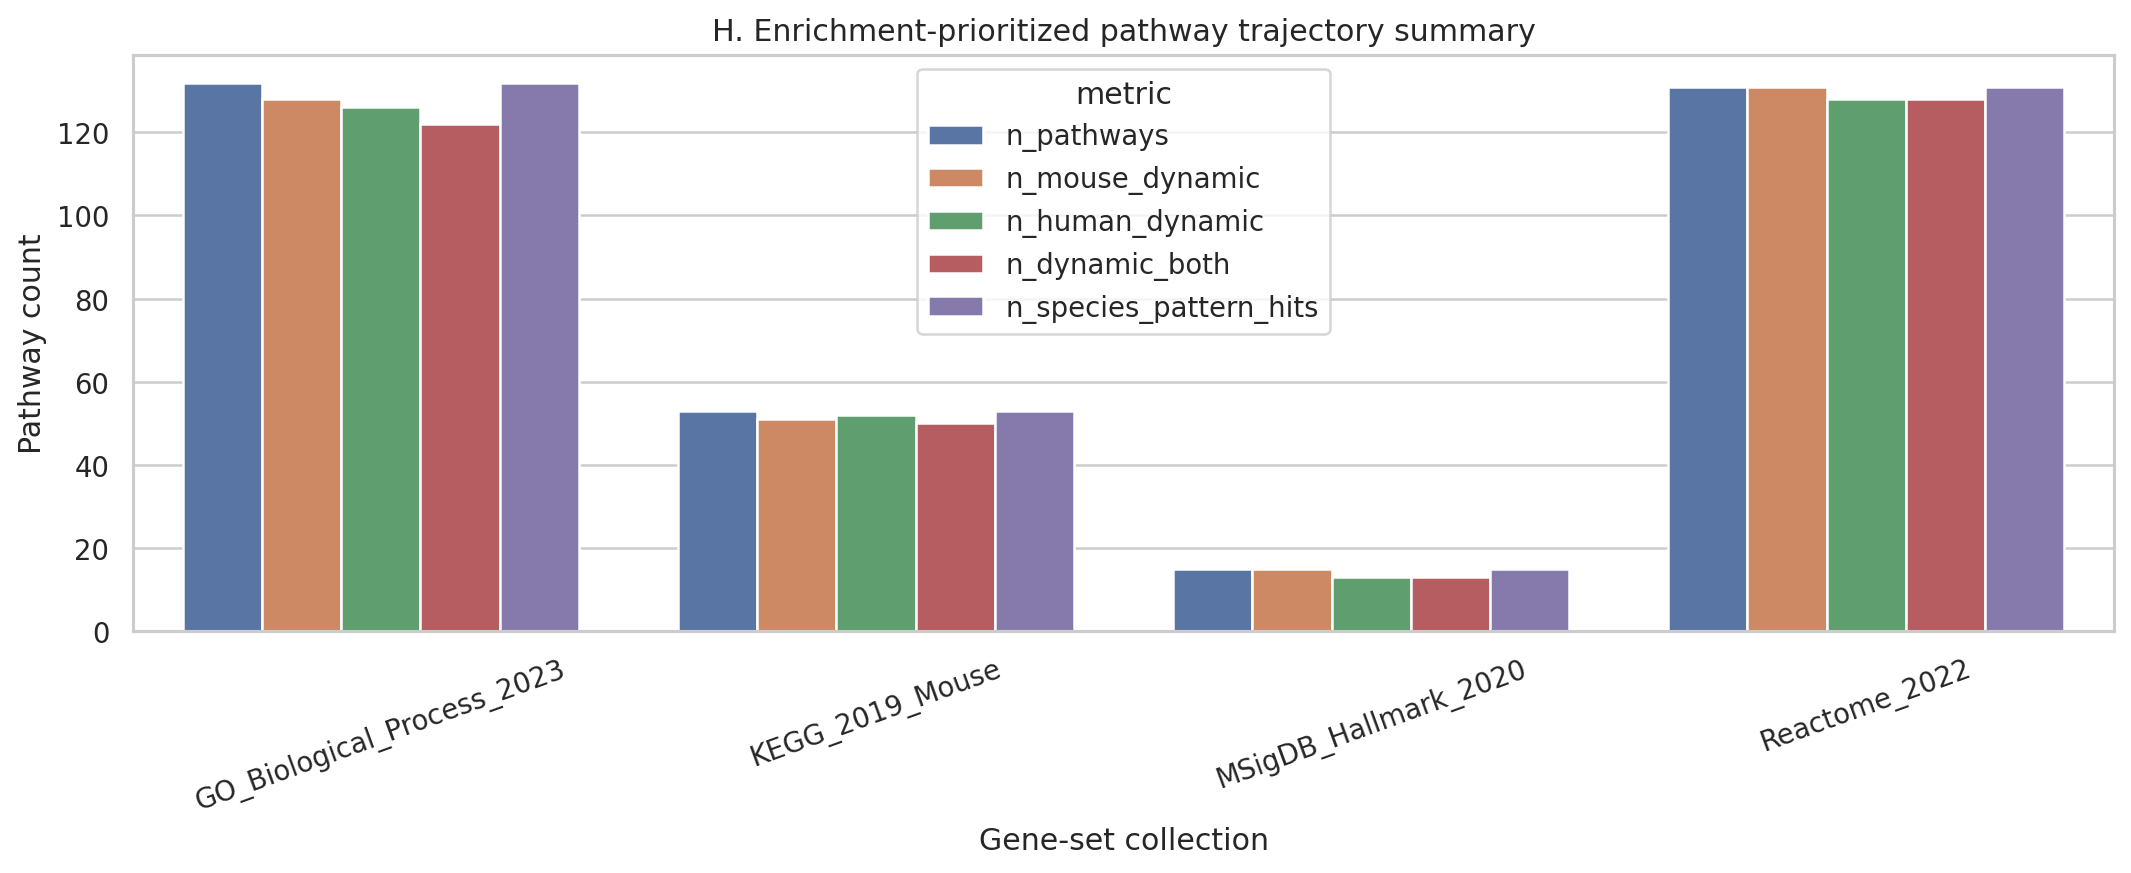

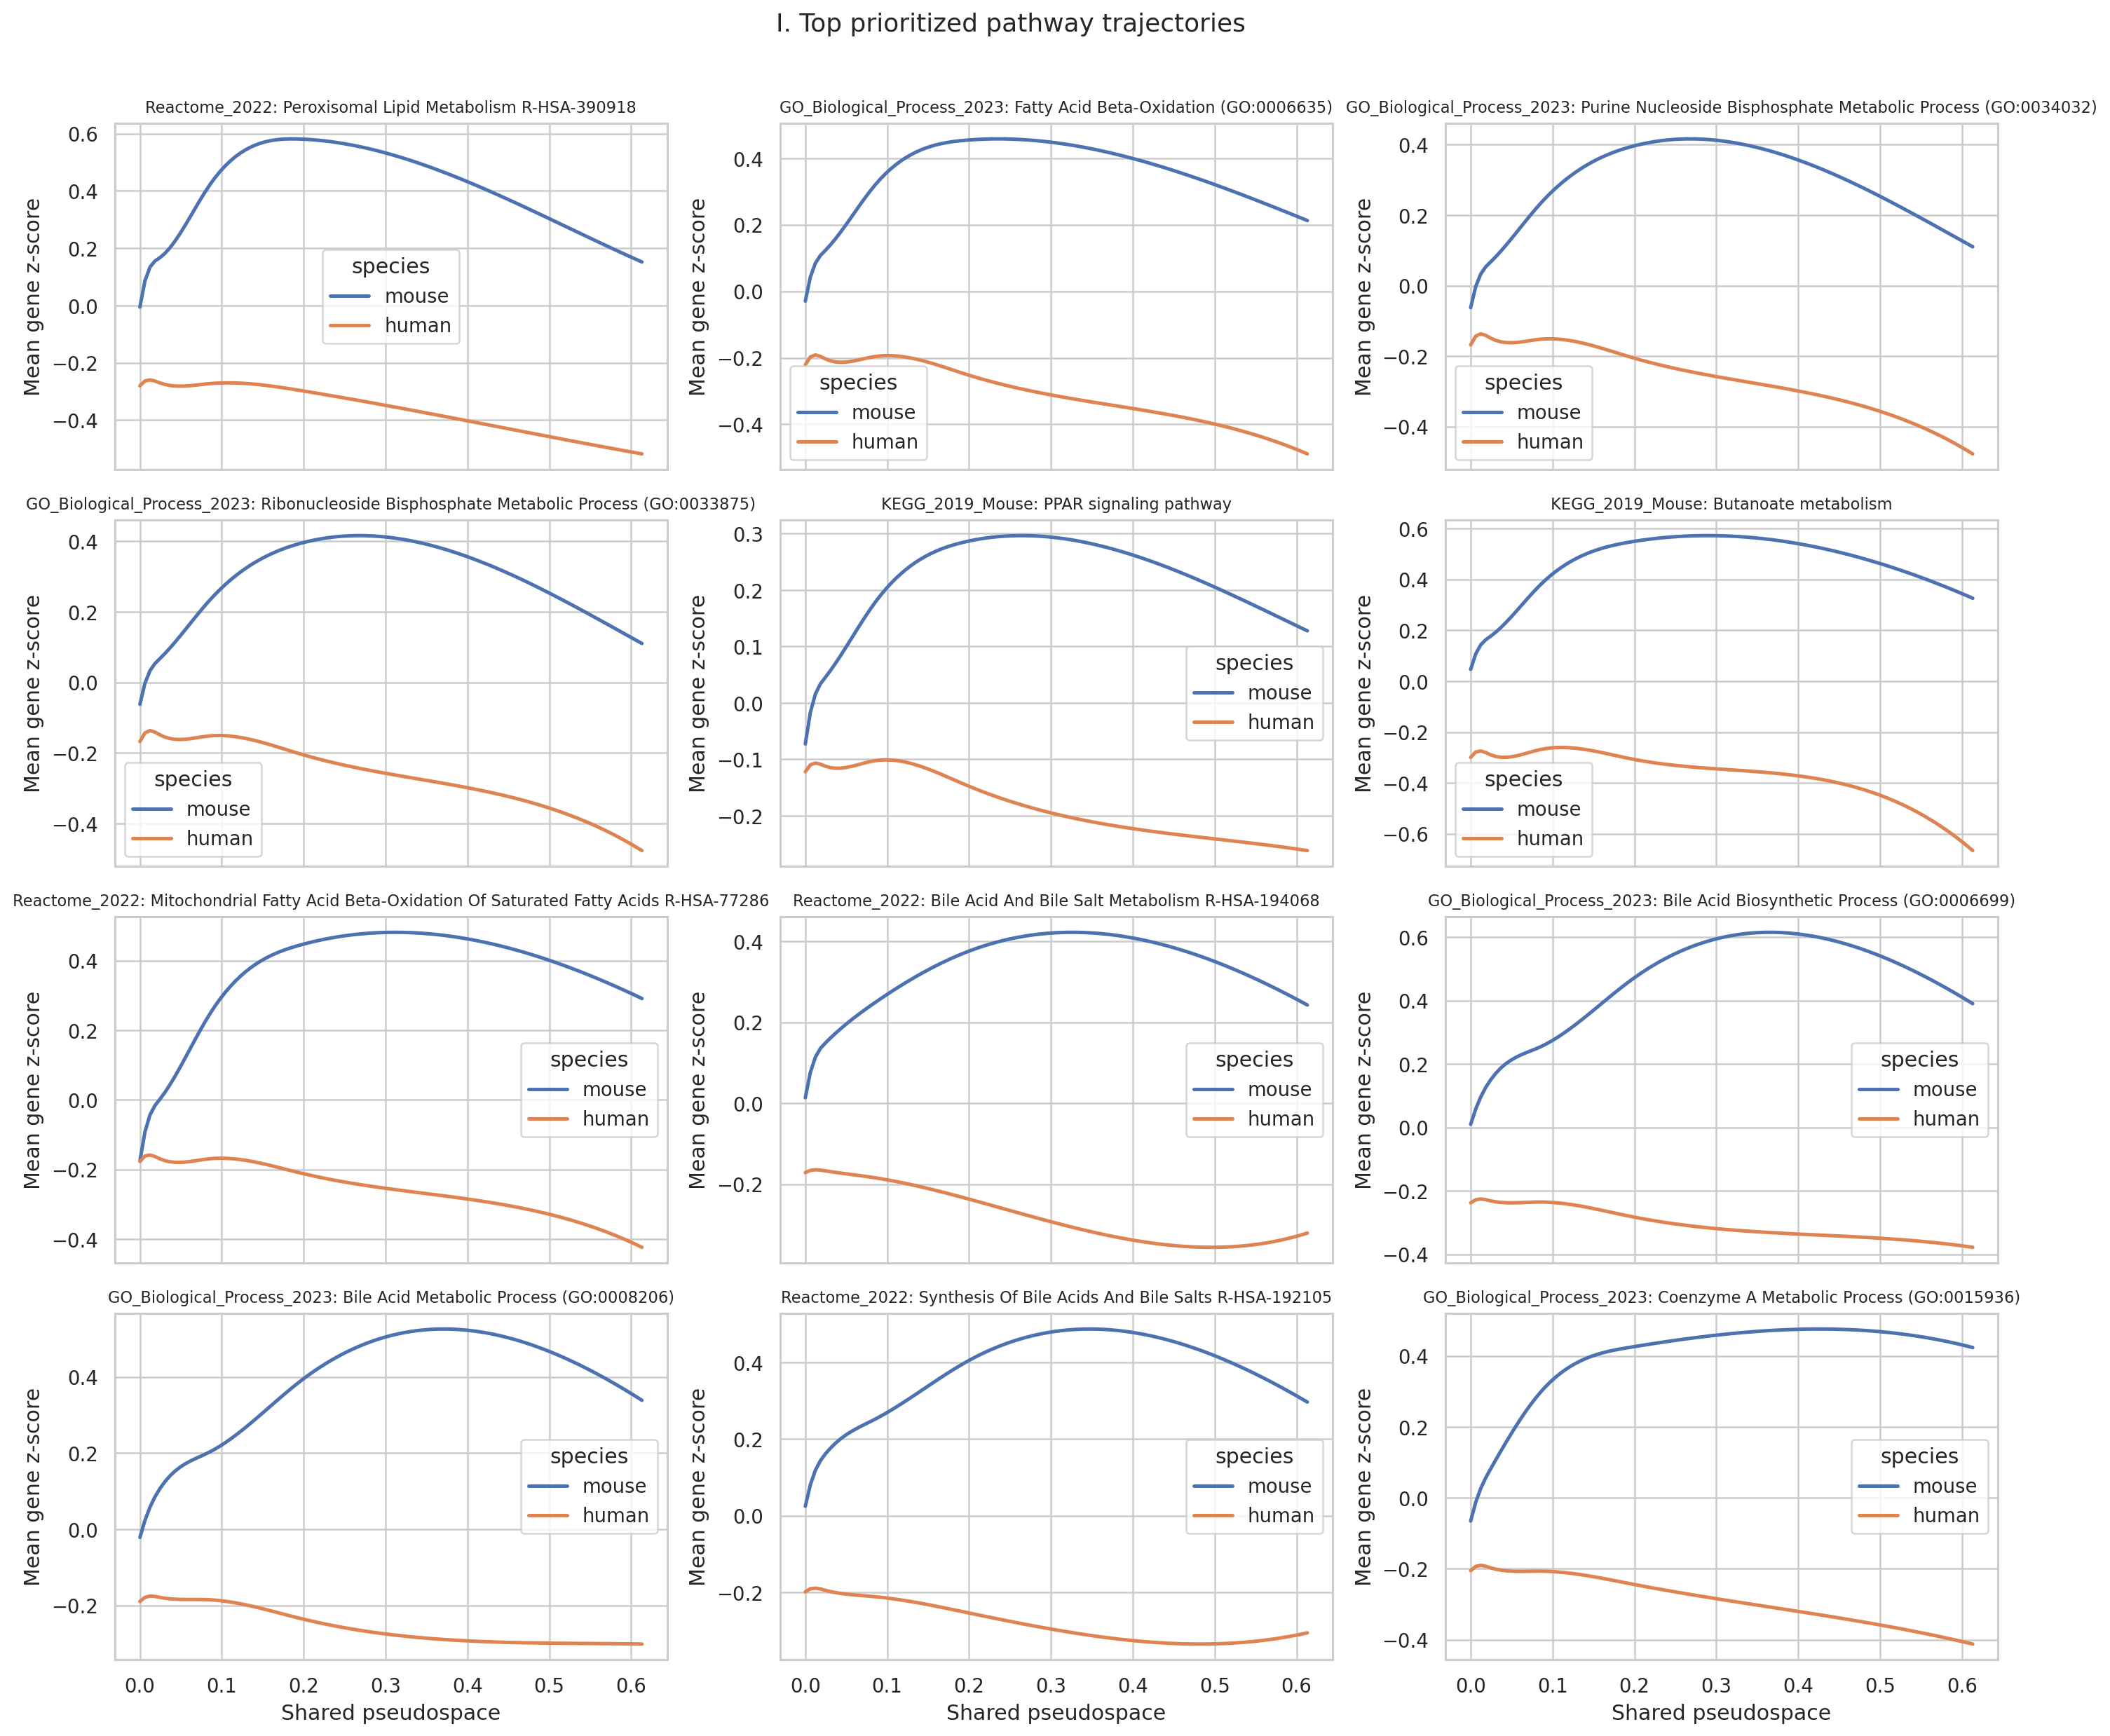

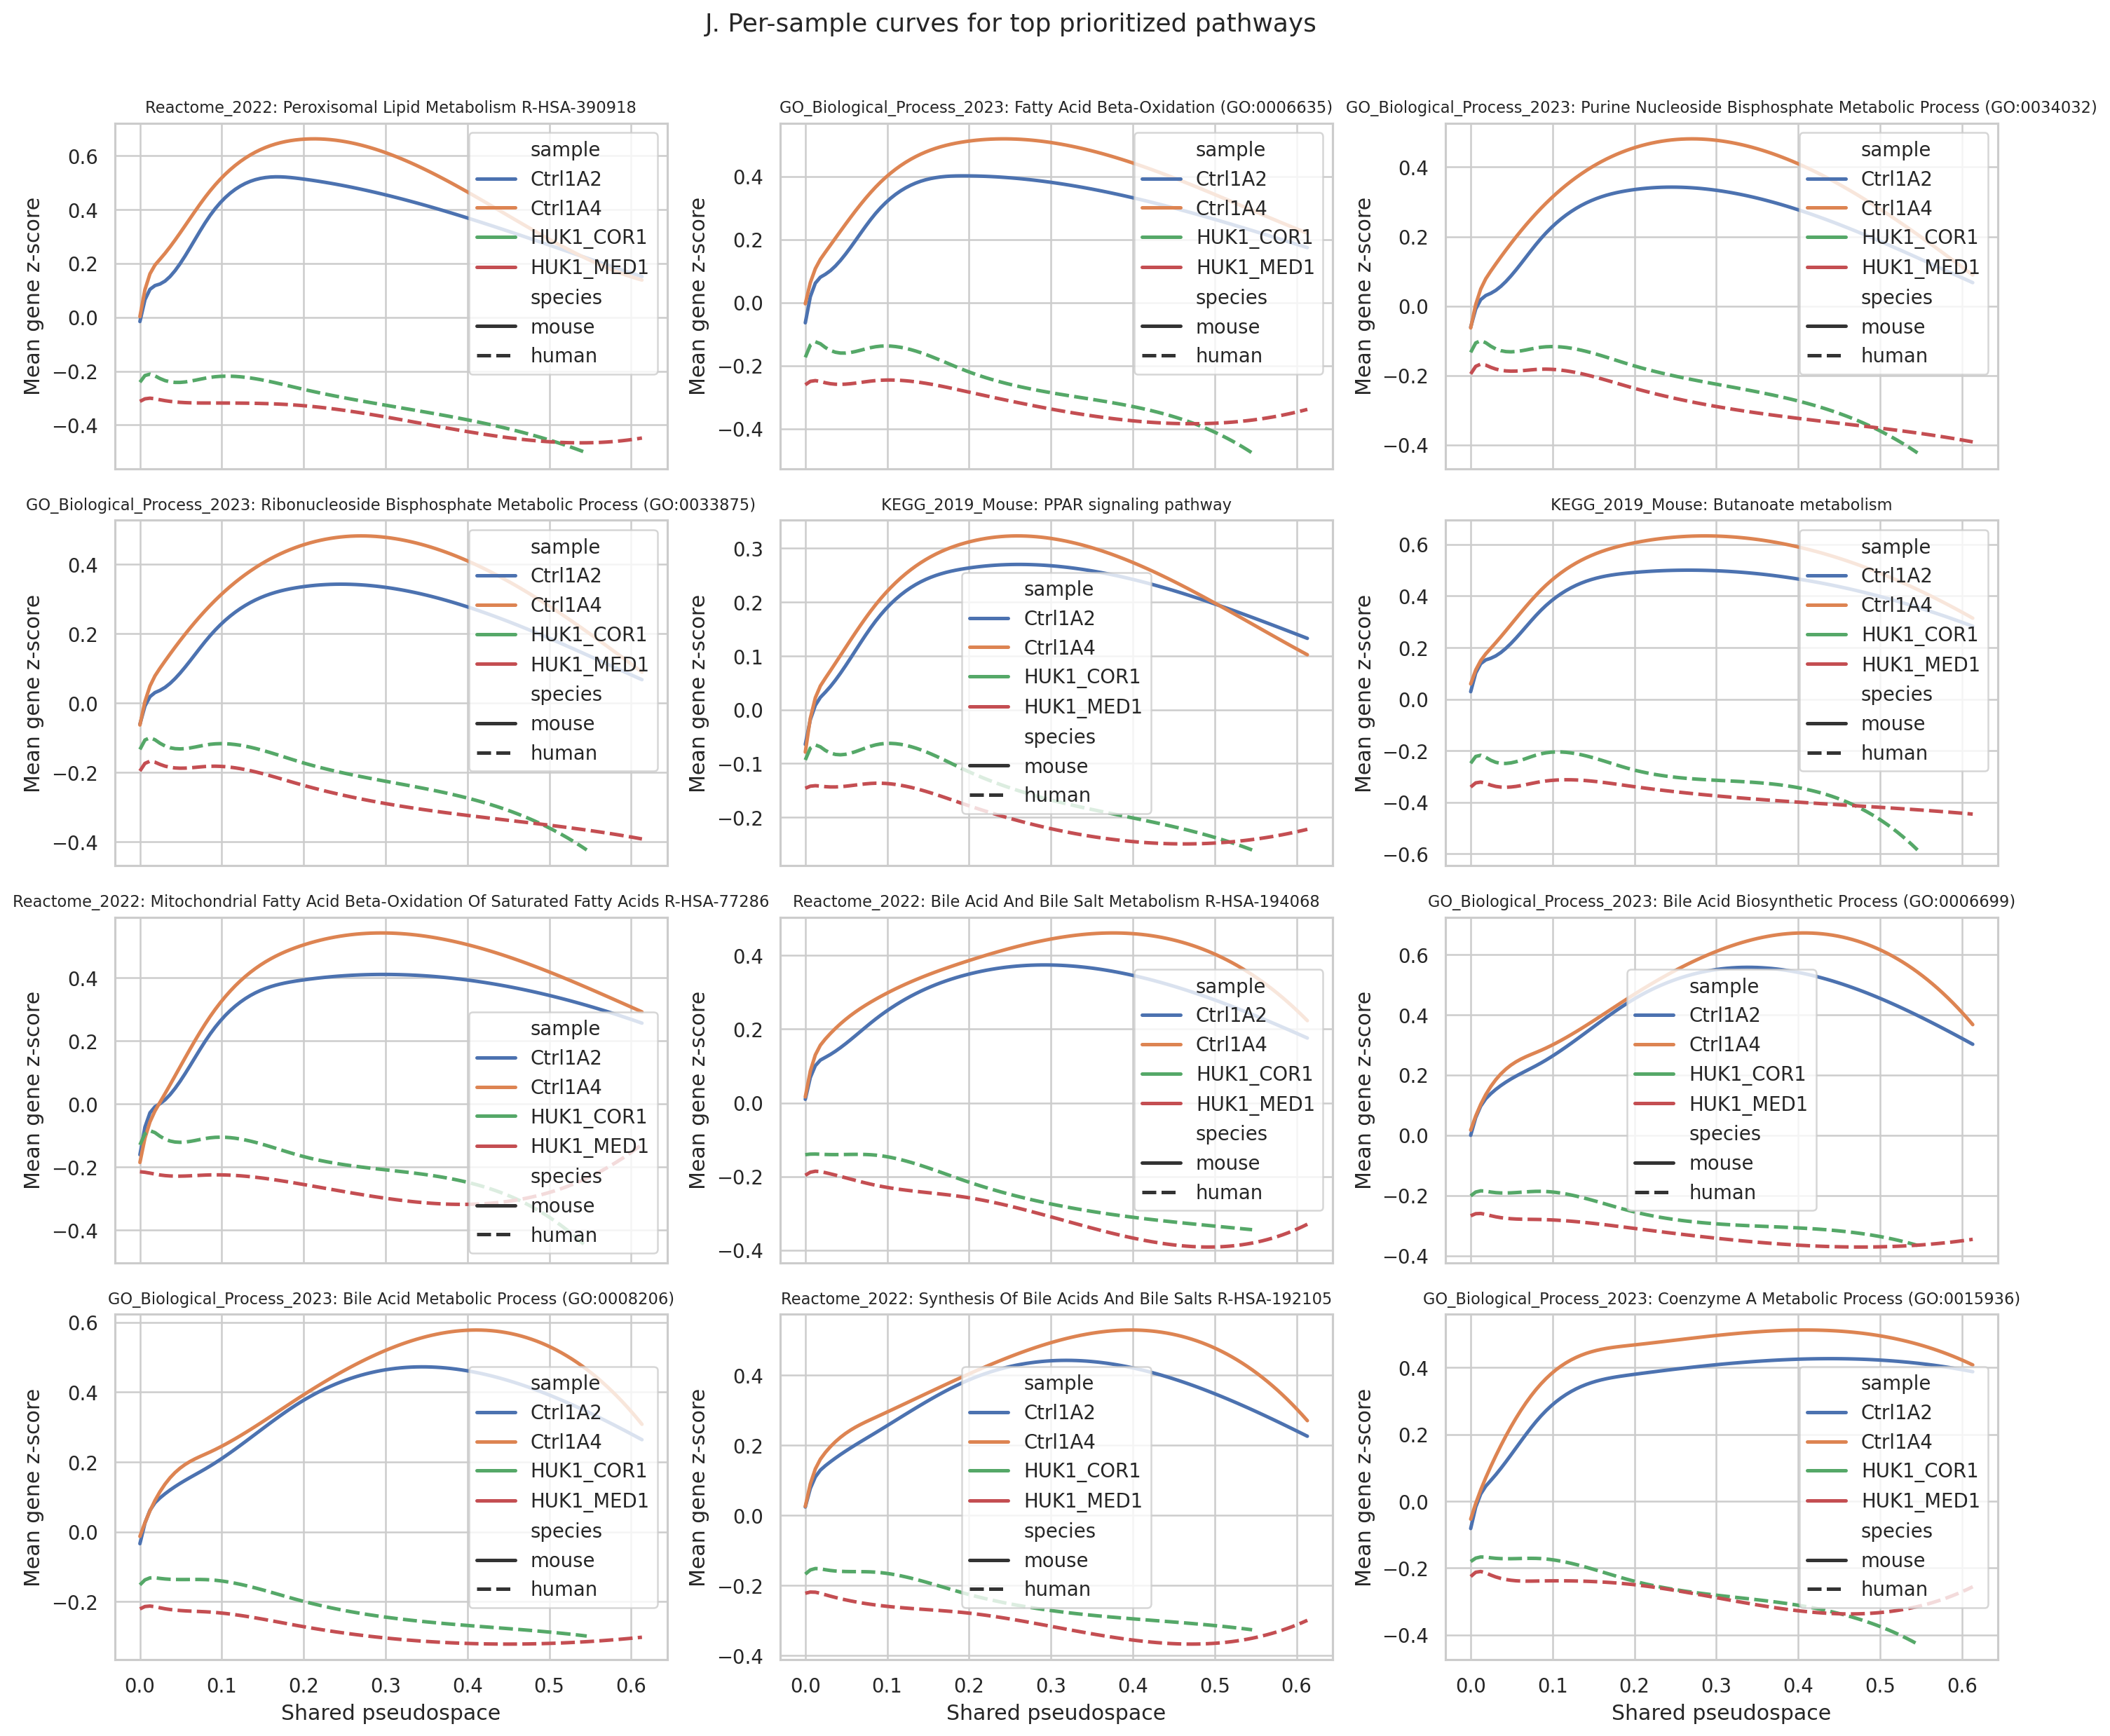

In [6]:
from scipy.stats import hypergeom

PATHWAY_LIBRARY_DIR = OUTPUT_DIR / 'pathway_gene_sets'
PATHWAY_LIBRARY_FILES = {
    'GO_Biological_Process_2023': PATHWAY_LIBRARY_DIR / 'GO_Biological_Process_2023.json',
    'Reactome_2022': PATHWAY_LIBRARY_DIR / 'Reactome_2022.json',
    'MSigDB_Hallmark_2020': PATHWAY_LIBRARY_DIR / 'MSigDB_Hallmark_2020.json',
    'KEGG_2019_Mouse': PATHWAY_LIBRARY_DIR / 'KEGG_2019_Mouse.json',
}
missing_pathway_files = [str(path) for path in PATHWAY_LIBRARY_FILES.values() if not path.exists()]
if missing_pathway_files:
    raise FileNotFoundError(f'Missing cached pathway libraries: {missing_pathway_files}')

KIDNEY_PT_CUSTOM_GENE_SETS = {
    'PT S1 glucose and bicarbonate reabsorption': [
        'Slc5a2', 'Slc2a2', 'Slc4a4', 'Slc9a3', 'Car2', 'Car4', 'Atp1a1', 'Atp1b1',
    ],
    'PT S2 organic anion secretion': [
        'Slc22a6', 'Slc22a8', 'Slc22a7', 'Slco4c1', 'Abcc2', 'Abcc4', 'Abcb1a', 'Abcb1b',
    ],
    'PT S3 amino acid transport': [
        'Slc7a13', 'Slc6a19', 'Slc3a1', 'Slc7a9', 'Slc36a2', 'Slc38a3', 'Slc5a8',
    ],
    'PT phosphate reabsorption': ['Slc34a1', 'Slc34a3', 'Slc20a2', 'Pth1r', 'Klotho', 'Atp1a1'],
    'PT receptor-mediated endocytosis': ['Lrp2', 'Cubn', 'Amn', 'Dab2', 'Cltc', 'Ap2a1', 'Ap2b1'],
    'PT fatty acid oxidation': ['Cpt1a', 'Acox1', 'Acadm', 'Acadl', 'Hadh', 'Acaa2', 'Echs1', 'Etfa'],
    'PT gluconeogenesis': ['Pck1', 'G6pc', 'Fbp1', 'Pc', 'Mdh1', 'Mdh2', 'Gatm'],
    'PT mitochondrial respiration': ['Ndufa1', 'Ndufa2', 'Ndufb3', 'Cox4i1', 'Cox5a', 'Atp5f1a'],
    'PT epithelial polarity': ['Cldn2', 'Tjp1', 'Cdh1', 'Epcam', 'Ezr', 'Pard3', 'Crb3'],
    'PT injury response': ['Havcr1', 'Lcn2', 'Vcam1', 'Spp1', 'Krt8', 'Krt18', 'Sox9'],
}


def dense_ols_sse(values, design):
    values = np.asarray(values, dtype=np.float64)
    x = np.asarray(design, dtype=np.float64)
    xty = x.T @ values
    beta = np.linalg.pinv(x) @ values
    yty = np.sum(values * values, axis=0)
    sse = yty - np.sum(beta * xty, axis=0)
    return np.maximum(sse, 0.0), beta


def dense_nested_f_test(values, reduced_design, full_design):
    sse_reduced, _ = dense_ols_sse(values, reduced_design)
    sse_full, beta_full = dense_ols_sse(values, full_design)
    df_num = full_design.shape[1] - reduced_design.shape[1]
    df_den = max(values.shape[0] - full_design.shape[1], 1)
    numerator = np.maximum(sse_reduced - sse_full, 0) / max(df_num, 1)
    denominator = np.maximum(sse_full / df_den, 1e-12)
    f_stat = numerator / denominator
    return f_stat, f_dist.sf(f_stat, df_num, df_den), beta_full


def dense_empirical_dynamic_pvalues(values, pseudospace, knots, observed_f, n_permutations, rng):
    null = np.ones((pseudospace.size, 1))
    sse_null, _ = dense_ols_sse(values, null)
    exceedances = np.zeros(values.shape[1], dtype=np.int32)
    for _ in range(n_permutations):
        shuffled = rng.permutation(pseudospace)
        permuted_design = make_design(shuffled, knots)
        sse_full, _ = dense_ols_sse(values, permuted_design)
        df_num = permuted_design.shape[1] - null.shape[1]
        df_den = max(values.shape[0] - permuted_design.shape[1], 1)
        numerator = np.maximum(sse_null - sse_full, 0) / max(df_num, 1)
        denominator = np.maximum(sse_full / df_den, 1e-12)
        exceedances += (numerator / denominator) >= observed_f
    return (exceedances + 1) / (n_permutations + 1)


def classify_pathway(row):
    if row['mouse_dynamic'] and not row['human_dynamic']:
        return 'mouse-specific gradient'
    if row['human_dynamic'] and not row['mouse_dynamic']:
        return 'human-specific gradient'
    if not row['mouse_dynamic'] and not row['human_dynamic']:
        return 'not dynamic in either'
    if not np.isfinite(row['curve_spearman']):
        return 'undefined curve correlation'
    if row['curve_spearman'] < 0:
        return 'divergent/reversed gradient'
    if abs(row['peak_shift_human_minus_mouse']) >= CONFIG['peak_shift_threshold']:
        return 'peak-shifted'
    if row['amplitude_ratio'] >= CONFIG['amplitude_ratio_threshold']:
        return 'conserved shape, amplitude-shifted'
    if row['curve_spearman'] >= CONFIG['conserved_curve_correlation']:
        return 'conserved dynamic'
    return 'divergent shape'


def build_dynamic_gene_lists(stats):
    both_dynamic = stats['mouse_dynamic'] & stats['human_dynamic']
    return {
        'mouse_dynamic_genes': stats.loc[stats['mouse_dynamic'], 'gene'].tolist(),
        'human_dynamic_genes': stats.loc[stats['human_dynamic'], 'gene'].tolist(),
        'conserved_dynamic_genes': stats.loc[
            both_dynamic & (stats['curve_spearman'] >= CONFIG['conserved_curve_correlation']), 'gene'
        ].tolist(),
        'species_divergent_genes': stats.loc[stats['significant_species_pattern'], 'gene'].tolist(),
        'mouse_specific_gradients': stats.loc[
            stats['mouse_dynamic'] & ~stats['human_dynamic'], 'gene'
        ].tolist(),
        'human_specific_gradients': stats.loc[
            stats['human_dynamic'] & ~stats['mouse_dynamic'], 'gene'
        ].tolist(),
        'peak_shifted_genes': stats.loc[
            both_dynamic & (stats['peak_shift_human_minus_mouse'].abs() >= CONFIG['peak_shift_threshold']), 'gene'
        ].tolist(),
    }


def normalize_gene_set(requested_genes, background_lookup):
    return sorted({
        background_lookup[gene.upper()]
        for gene in requested_genes
        if isinstance(gene, str) and gene.upper() in background_lookup
    })


def run_functional_enrichment(raw_libraries, gene_lists, background_genes):
    background_lookup = {gene.upper(): gene for gene in background_genes}
    background_set = set(background_genes)
    background_size = len(background_set)
    rows = []
    eligible_terms = []
    for library, gene_sets in raw_libraries.items():
        for term, requested_genes in gene_sets.items():
            term_genes = normalize_gene_set(requested_genes, background_lookup)
            if CONFIG['pathway_min_genes'] <= len(term_genes) <= CONFIG['pathway_max_genes']:
                eligible_terms.append((library, term, term_genes, set(term_genes)))
    for gene_list_name, list_genes in gene_lists.items():
        query_genes = sorted(set(list_genes) & background_set)
        query_size = len(query_genes)
        query_set = set(query_genes)
        for library, term, term_genes, term_set in eligible_terms:
            overlap_genes = sorted(query_set & term_set)
            overlap = len(overlap_genes)
            if query_size == 0:
                pvalue = 1.0
            else:
                pvalue = hypergeom.sf(overlap - 1, background_size, len(term_genes), query_size)
            rows.append({
                'gene_list': gene_list_name,
                'library': library,
                'pathway': term,
                'background_size': background_size,
                'query_size': query_size,
                'term_size_background': len(term_genes),
                'overlap': overlap,
                'pvalue': pvalue,
                'overlap_genes': ';'.join(overlap_genes),
                'genes_present': ';'.join(term_genes),
                'n_genes_present': len(term_genes),
                'gene_list_members': ';'.join(query_genes),
                'term_gene_list': term_genes,
            })
    enrichment = pd.DataFrame(rows)
    if enrichment.empty:
        return enrichment
    enrichment['padj'] = np.nan
    for gene_list_name, idx in enrichment.groupby('gene_list', observed=True).groups.items():
        enrichment.loc[idx, 'padj'] = bh_adjust(enrichment.loc[idx, 'pvalue'].to_numpy())
    enrichment['significant_enrichment'] = (
        (enrichment['padj'] < CONFIG['enrichment_fdr'])
        & (enrichment['overlap'] >= CONFIG['enrichment_min_overlap'])
    )
    return enrichment.sort_values(['gene_list', 'padj', 'overlap'], ascending=[True, True, False])


def prioritize_enriched_pathways(enrichment):
    priority_order = {
        name: i for i, name in enumerate(CONFIG.get('enrichment_priority_classes', []))
    }
    significant = enrichment.loc[enrichment['significant_enrichment']].copy()
    if significant.empty:
        return pd.DataFrame(), significant
    significant['priority_rank'] = significant['gene_list'].map(priority_order).fillna(len(priority_order)).astype(int)
    significant = significant.sort_values(
        ['priority_rank', 'padj', 'overlap', 'term_size_background'],
        ascending=[True, True, False, True],
    )
    pathway_rows = []
    for (library, pathway), group in significant.groupby(['library', 'pathway'], sort=False, observed=True):
        best = group.iloc[0]
        pathway_rows.append({
            'library': library,
            'pathway': pathway,
            'genes_present': best['genes_present'],
            'n_genes_present': int(best['n_genes_present']),
            'enriched_gene_lists': ';'.join(group['gene_list'].drop_duplicates().tolist()),
            'best_enrichment_gene_list': best['gene_list'],
            'best_enrichment_pvalue': best['pvalue'],
            'best_enrichment_padj': best['padj'],
            'best_enrichment_overlap': int(best['overlap']),
            'gene_list': best['term_gene_list'],
        })
    return pd.DataFrame(pathway_rows), significant


raw_pathway_libraries = {
    library: json.loads(path.read_text())
    for library, path in PATHWAY_LIBRARY_FILES.items()
}
raw_pathway_libraries['Kidney_PT_Custom'] = KIDNEY_PT_CUSTOM_GENE_SETS

dynamic_gene_lists = build_dynamic_gene_lists(ortholog_stats)
gene_list_summary = pd.DataFrame([
    {'gene_list': name, 'n_genes': len(sorted(set(values) & set(genes)))}
    for name, values in dynamic_gene_lists.items()
])
gene_list_summary.to_csv(OUTPUT_DIR / 'functional_enrichment_gene_list_summary.csv', index=False)

functional_enrichment = run_functional_enrichment(raw_pathway_libraries, dynamic_gene_lists, genes)
if functional_enrichment.empty:
    raise ValueError('No functional terms passed the background term-size thresholds')
functional_enrichment.drop(columns='term_gene_list').to_csv(
    OUTPUT_DIR / 'functional_enrichment_all_terms.csv', index=False
)
retained_pathways, significant_enrichment = prioritize_enriched_pathways(functional_enrichment)
significant_enrichment.drop(columns='term_gene_list').to_csv(
    OUTPUT_DIR / 'functional_enrichment_significant_terms.csv', index=False
)
if retained_pathways.empty:
    raise ValueError(
        'No enriched functional terms passed the adjusted-P, overlap, and term-size filters'
    )
retained_pathways.to_csv(OUTPUT_DIR / 'prioritized_enriched_pathways_for_spline_modeling.csv', index=False)

# Score tubules as the mean member-gene z-score without materializing a dense gene-z matrix.
pathway_gene_names = sorted({gene for values in retained_pathways['gene_list'] for gene in values})
pathway_gene_indices = [gene_index[gene] for gene in pathway_gene_names]
pathway_gene_local = {gene: i for i, gene in enumerate(pathway_gene_names)}
pathway_expression = test_matrix[:, pathway_gene_indices].tocsr().astype(np.float64)
gene_means = np.asarray(pathway_expression.mean(axis=0)).ravel()
gene_sq_means = np.asarray(pathway_expression.multiply(pathway_expression).mean(axis=0)).ravel()
gene_stds = np.sqrt(np.maximum(gene_sq_means - gene_means**2, 0))
gene_stds[gene_stds == 0] = 1.0
pathway_scores = np.empty((adata_pt.n_obs, len(retained_pathways)), dtype=np.float32)
for pathway_i, member_genes in enumerate(retained_pathways['gene_list']):
    member_indices = [pathway_gene_local[gene] for gene in member_genes]
    weights = 1.0 / gene_stds[member_indices]
    offset = np.mean(gene_means[member_indices] / gene_stds[member_indices])
    pathway_scores[:, pathway_i] = (
        np.asarray(pathway_expression[:, member_indices] @ weights).ravel() / len(member_indices) - offset
    )

pooled_pseudospace = adata_pt.obs['shared_pseudospace'].to_numpy(dtype=float)
pathway_knots = np.quantile(pooled_pseudospace, [0.25, 0.50, 0.75])
pathway_grid_design = make_design(grid, pathway_knots)
pathway_species_results = {}
pathway_rng = np.random.default_rng(CONFIG['permutation_seed'])
for species in ['mouse', 'human']:
    species_mask = adata_pt.obs['comparison_species'].eq(species).to_numpy()
    species_values = pathway_scores[species_mask]
    species_pseudospace = pooled_pseudospace[species_mask]
    species_design = make_design(species_pseudospace, pathway_knots)
    null = np.ones((species_pseudospace.size, 1))
    f_stat, parametric_pvalue, beta = dense_nested_f_test(species_values, null, species_design)
    permutation_pvalue = dense_empirical_dynamic_pvalues(
        species_values,
        species_pseudospace,
        pathway_knots,
        f_stat,
        CONFIG['dynamic_permutations'],
        pathway_rng,
    )
    curves = (pathway_grid_design @ beta).T
    amplitude = np.ptp(curves, axis=1)
    permutation_padj = bh_adjust(permutation_pvalue)
    pathway_species_results[species] = {
        'curves': curves,
        'amplitude': amplitude,
        'parametric_pvalue': parametric_pvalue,
        'parametric_padj': bh_adjust(parametric_pvalue),
        'permutation_pvalue': permutation_pvalue,
        'permutation_padj': permutation_padj,
        'dynamic': (permutation_padj < CONFIG['dynamic_fdr']) & (amplitude >= CONFIG['min_dynamic_amplitude']),
    }

species_indicator = adata_pt.obs['comparison_species'].eq('human').to_numpy(dtype=float)
pooled_spline = make_design(pooled_pseudospace, pathway_knots)[:, 1:]
interaction_reduced = np.column_stack([np.ones(pooled_pseudospace.size), species_indicator, pooled_spline])
interaction_full = np.column_stack([interaction_reduced, pooled_spline * species_indicator[:, None]])
interaction_f, interaction_p, _ = dense_nested_f_test(pathway_scores, interaction_reduced, interaction_full)

pathway_mouse = pathway_species_results['mouse']
pathway_human = pathway_species_results['human']
pathway_corr = rowwise_curve_correlation(pathway_mouse['curves'], pathway_human['curves'])
pathway_mouse_peak = grid[np.argmax(pathway_mouse['curves'], axis=1)]
pathway_human_peak = grid[np.argmax(pathway_human['curves'], axis=1)]
pathway_amplitude_ratio = np.maximum(pathway_mouse['amplitude'], pathway_human['amplitude']) / np.maximum(
    np.minimum(pathway_mouse['amplitude'], pathway_human['amplitude']), 1e-6
)
pathway_stats = retained_pathways.drop(columns='gene_list').copy()
pathway_stats = pathway_stats.assign(
    mouse_dynamic_permutation_pvalue=pathway_mouse['permutation_pvalue'],
    mouse_dynamic_permutation_padj=pathway_mouse['permutation_padj'],
    mouse_dynamic_parametric_pvalue=pathway_mouse['parametric_pvalue'],
    mouse_dynamic_parametric_padj=pathway_mouse['parametric_padj'],
    human_dynamic_permutation_pvalue=pathway_human['permutation_pvalue'],
    human_dynamic_permutation_padj=pathway_human['permutation_padj'],
    human_dynamic_parametric_pvalue=pathway_human['parametric_pvalue'],
    human_dynamic_parametric_padj=pathway_human['parametric_padj'],
    mouse_dynamic=pathway_mouse['dynamic'],
    human_dynamic=pathway_human['dynamic'],
    mouse_amplitude=pathway_mouse['amplitude'],
    human_amplitude=pathway_human['amplitude'],
    amplitude_difference_human_minus_mouse=pathway_human['amplitude'] - pathway_mouse['amplitude'],
    amplitude_ratio=pathway_amplitude_ratio,
    curve_spearman=pathway_corr,
    mouse_peak_pseudospace=pathway_mouse_peak,
    human_peak_pseudospace=pathway_human_peak,
    peak_shift_human_minus_mouse=pathway_human_peak - pathway_mouse_peak,
    interaction_f_stat=interaction_f,
    interaction_pvalue=interaction_p,
    interaction_padj=bh_adjust(interaction_p),
)
pathway_stats['significant_species_pattern'] = pathway_stats['interaction_padj'] < CONFIG['interaction_fdr']
pathway_stats['conservation_class'] = pathway_stats.apply(classify_pathway, axis=1)
pathway_stats = pathway_stats.sort_values(
    ['significant_species_pattern', 'interaction_padj', 'curve_spearman'],
    ascending=[False, True, False],
)
pathway_stats.to_csv(OUTPUT_DIR / 'pathway_trajectory_classification.csv', index=False)
pathway_stats.loc[pathway_stats['significant_species_pattern']].to_csv(
    OUTPUT_DIR / 'pathway_species_pattern_interaction_hits.csv', index=False
)

pathway_library_summary = (
    pathway_stats.groupby('library', observed=True)
    .agg(
        n_pathways=('pathway', 'size'),
        n_mouse_dynamic=('mouse_dynamic', 'sum'),
        n_human_dynamic=('human_dynamic', 'sum'),
        n_dynamic_both=('pathway', lambda values: int(
            (pathway_stats.loc[values.index, 'mouse_dynamic'] & pathway_stats.loc[values.index, 'human_dynamic']).sum()
        )),
        n_species_pattern_hits=('significant_species_pattern', 'sum'),
    )
    .reset_index()
)
pathway_library_summary.to_csv(OUTPUT_DIR / 'pathway_library_summary.csv', index=False)

curve_rows = []
for pathway_i, row in retained_pathways.iterrows():
    for species, result in pathway_species_results.items():
        for x, value in zip(grid, result['curves'][pathway_i]):
            curve_rows.append({
                'library': row['library'], 'pathway': row['pathway'], 'species': species,
                'pseudospace': x, 'fitted_pathway_score': value,
            })
pathway_fitted_curves = pd.DataFrame(curve_rows)
pathway_fitted_curves.to_csv(OUTPUT_DIR / 'pathway_fitted_curves.csv', index=False)

top_pathways = pathway_stats.loc[pathway_stats['significant_species_pattern']].head(
    CONFIG['pathway_top_plot']
)[['library', 'pathway']]
if top_pathways.empty:
    top_pathways = pathway_stats.head(CONFIG['pathway_top_plot'])[['library', 'pathway']]
top_pathway_curves = pathway_fitted_curves.merge(top_pathways, on=['library', 'pathway'], how='inner')

# Sample-level sensitivity curves for the top divergent pathways.
top_indices = [
    retained_pathways.index[
        (retained_pathways['library'].eq(row.library)) & (retained_pathways['pathway'].eq(row.pathway))
    ][0]
    for row in top_pathways.itertuples(index=False)
]
sample_pathway_rows = []
for sample in adata_pt.obs['sample'].astype(str).unique():
    sample_mask = adata_pt.obs['sample'].astype(str).eq(sample).to_numpy()
    sample_pseudospace = pooled_pseudospace[sample_mask]
    sample_design = make_design(sample_pseudospace, pathway_knots)
    _, sample_beta = dense_ols_sse(pathway_scores[sample_mask][:, top_indices], sample_design)
    sample_curves = (pathway_grid_design @ sample_beta).T
    supported = (grid >= np.min(sample_pseudospace)) & (grid <= np.max(sample_pseudospace))
    sample_curves[:, ~supported] = np.nan
    sample_species_label = adata_pt.obs.loc[sample_mask, 'comparison_species'].astype(str).iloc[0]
    for curve_i, row in enumerate(top_pathways.itertuples(index=False)):
        for x, value in zip(grid, sample_curves[curve_i]):
            sample_pathway_rows.append({
                'library': row.library, 'pathway': row.pathway, 'sample': sample,
                'species': sample_species_label, 'pseudospace': x, 'fitted_pathway_score': value,
            })
top_sample_pathway_curves = pd.DataFrame(sample_pathway_rows)
top_sample_pathway_curves.to_csv(OUTPUT_DIR / 'top_pathway_per_sample_curves.csv', index=False)

print(f'Gene lists enriched: {len(dynamic_gene_lists):,}')
print(f'Significant enriched term instances: {len(significant_enrichment):,}')
print(f'Prioritized pathway sets for spline modeling: {len(pathway_stats):,}')
print(f"Dynamic pathways in mouse: {int(pathway_stats['mouse_dynamic'].sum()):,}")
print(f"Dynamic pathways in human: {int(pathway_stats['human_dynamic'].sum()):,}")
print(f"Dynamic pathways in both: {int((pathway_stats['mouse_dynamic'] & pathway_stats['human_dynamic']).sum()):,}")
print(f"Pathway species-pattern hits: {int(pathway_stats['significant_species_pattern'].sum()):,}")
print('\nPathway library summary:')
print(pathway_library_summary.to_string(index=False))

# Figure H: pathway-library summary.
summary_plot = pathway_library_summary.melt(
    id_vars='library',
    value_vars=['n_pathways', 'n_mouse_dynamic', 'n_human_dynamic', 'n_dynamic_both', 'n_species_pattern_hits'],
    var_name='metric', value_name='count',
)
fig, ax = plt.subplots(figsize=(12, 5))
sns.barplot(data=summary_plot, x='library', y='count', hue='metric', ax=ax)
ax.set(title='H. Enrichment-prioritized pathway trajectory summary', xlabel='Gene-set collection', ylabel='Pathway count')
ax.tick_params(axis='x', rotation=20)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'H_pathway_library_summary.png', bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(OUTPUT_DIR / 'H_pathway_library_summary.png')))

# Figure I: species curves for top divergent pathways.
ncols = 3
nrows = max(1, int(np.ceil(len(top_pathways) / ncols)))
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.4 * nrows), sharex=True)
axes = np.atleast_1d(axes).ravel()
for ax, row in zip(axes, top_pathways.itertuples(index=False)):
    subset = top_pathway_curves.loc[
        top_pathway_curves['library'].eq(row.library) & top_pathway_curves['pathway'].eq(row.pathway)
    ]
    sns.lineplot(data=subset, x='pseudospace', y='fitted_pathway_score', hue='species', ax=ax, linewidth=2)
    ax.set_title(f'{row.library}: {row.pathway}', fontsize=9)
    ax.set_xlabel('Shared pseudospace')
    ax.set_ylabel('Mean gene z-score')
for ax in axes[len(top_pathways):]:
    ax.axis('off')
fig.suptitle('I. Top prioritized pathway trajectories', y=1.01)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'I_top_divergent_pathway_trajectories.png', bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(OUTPUT_DIR / 'I_top_divergent_pathway_trajectories.png')))

# Figure J: per-sample curves for top divergent pathways.
fig, axes = plt.subplots(nrows, ncols, figsize=(16, 3.4 * nrows), sharex=True)
axes = np.atleast_1d(axes).ravel()
for ax, row in zip(axes, top_pathways.itertuples(index=False)):
    subset = top_sample_pathway_curves.loc[
        top_sample_pathway_curves['library'].eq(row.library)
        & top_sample_pathway_curves['pathway'].eq(row.pathway)
    ]
    sns.lineplot(
        data=subset, x='pseudospace', y='fitted_pathway_score', hue='sample',
        style='species', ax=ax, linewidth=2,
    )
    ax.set_title(f'{row.library}: {row.pathway}', fontsize=9)
    ax.set_xlabel('Shared pseudospace')
    ax.set_ylabel('Mean gene z-score')
for ax in axes[len(top_pathways):]:
    ax.axis('off')
fig.suptitle('J. Per-sample curves for top prioritized pathways', y=1.01)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'J_top_pathway_per_sample_curves.png', bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(OUTPUT_DIR / 'J_top_pathway_per_sample_curves.png')))


## Segment-wise conservation scores and visualization

Equal-width bins are used only for descriptive conservation summaries after the
tubule-level spline models have been fitted. Segment-wise conservation is quantified
using genes classified as dynamic in at least one species. For each of the `30` shared
pseudospace bins, the analysis correlates
the mouse and human vectors of mean log-normalized expression across this dynamic-gene
set. Spearman correlation between matched mouse and human bin positions is reported as
the segment-wise conservation score. The full `30 x 30` cross-bin matrix is also
calculated to show agreement between every mouse-bin and human-bin combination.

Bins without sufficient finite values are retained as missing values. No interpolation
is applied. The matched-position scores and full cross-bin matrix are written to
`segmentwise_conservation_score.csv` and
`cross_species_bin_correlation_matrix.csv`.

For the conserved-dynamic heatmap, genes dynamic in both species are ranked by
mouse-human fitted-curve correlation. The first `60` genes are displayed after
within-gene, within-species z-score standardization. If no genes are dynamic in both
species, the fallback set is genes dynamic in either species.

The following output figures are generated:

- `A_canonical_marker_gradients.png`: canonical S1-S3 marker trajectories.
- `B_conserved_dynamic_ortholog_heatmap.png`: paired mouse and human dynamic-gene heatmaps.
- `C_peak_shift_scatter.png`: mouse versus human fitted peak positions, colored by curve correlation and sized by amplitude ratio.
- `D_pathway_module_trajectories.png`: mouse and human functional-module trajectories.
- `F_per_sample_marker_curves.png`: sample-specific curves for every retained canonical marker.
- `G_per_sample_module_curves.png`: sample-specific curves for every retained pathway module.
- `E_segmentwise_conservation.png`: matched-position conservation and full cross-bin agreement.
- `mouse_vs_human_PT_summary_figure.png`: combined manuscript-oriented overview.


Each saved PNG is displayed inline immediately after it is written so that the executed
notebook contains the complete visual output without requiring separate file browsing.


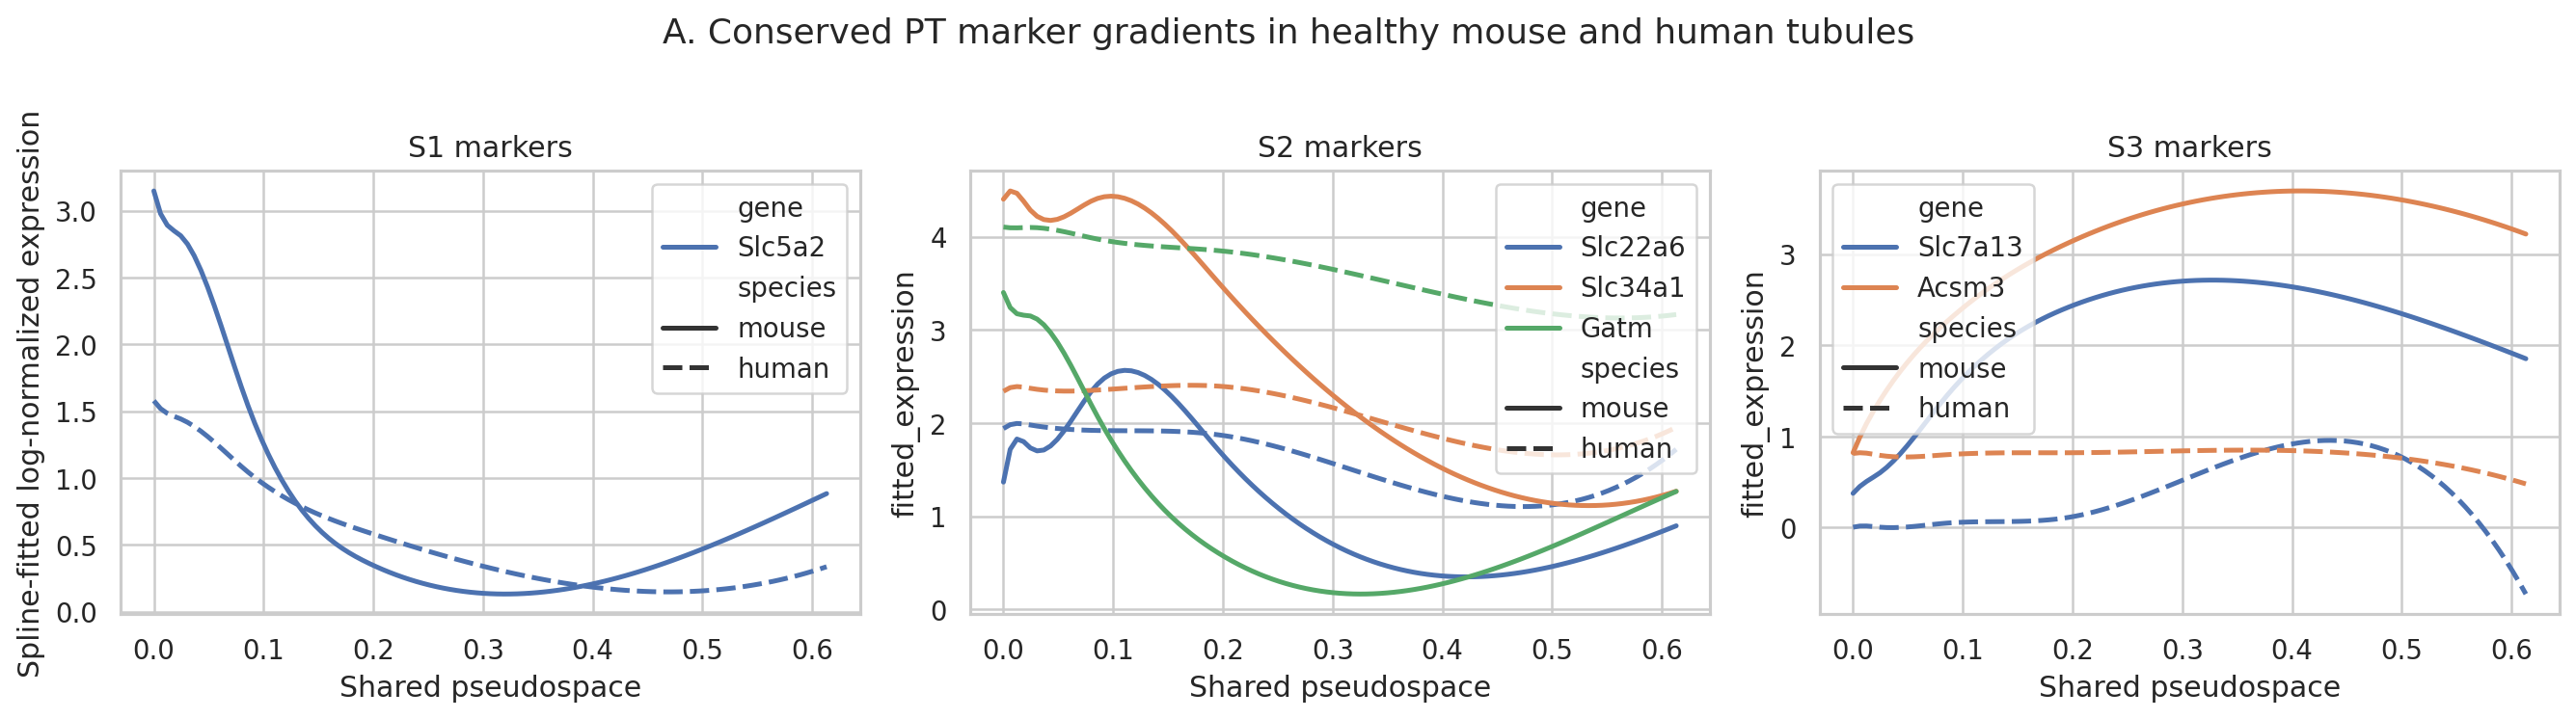

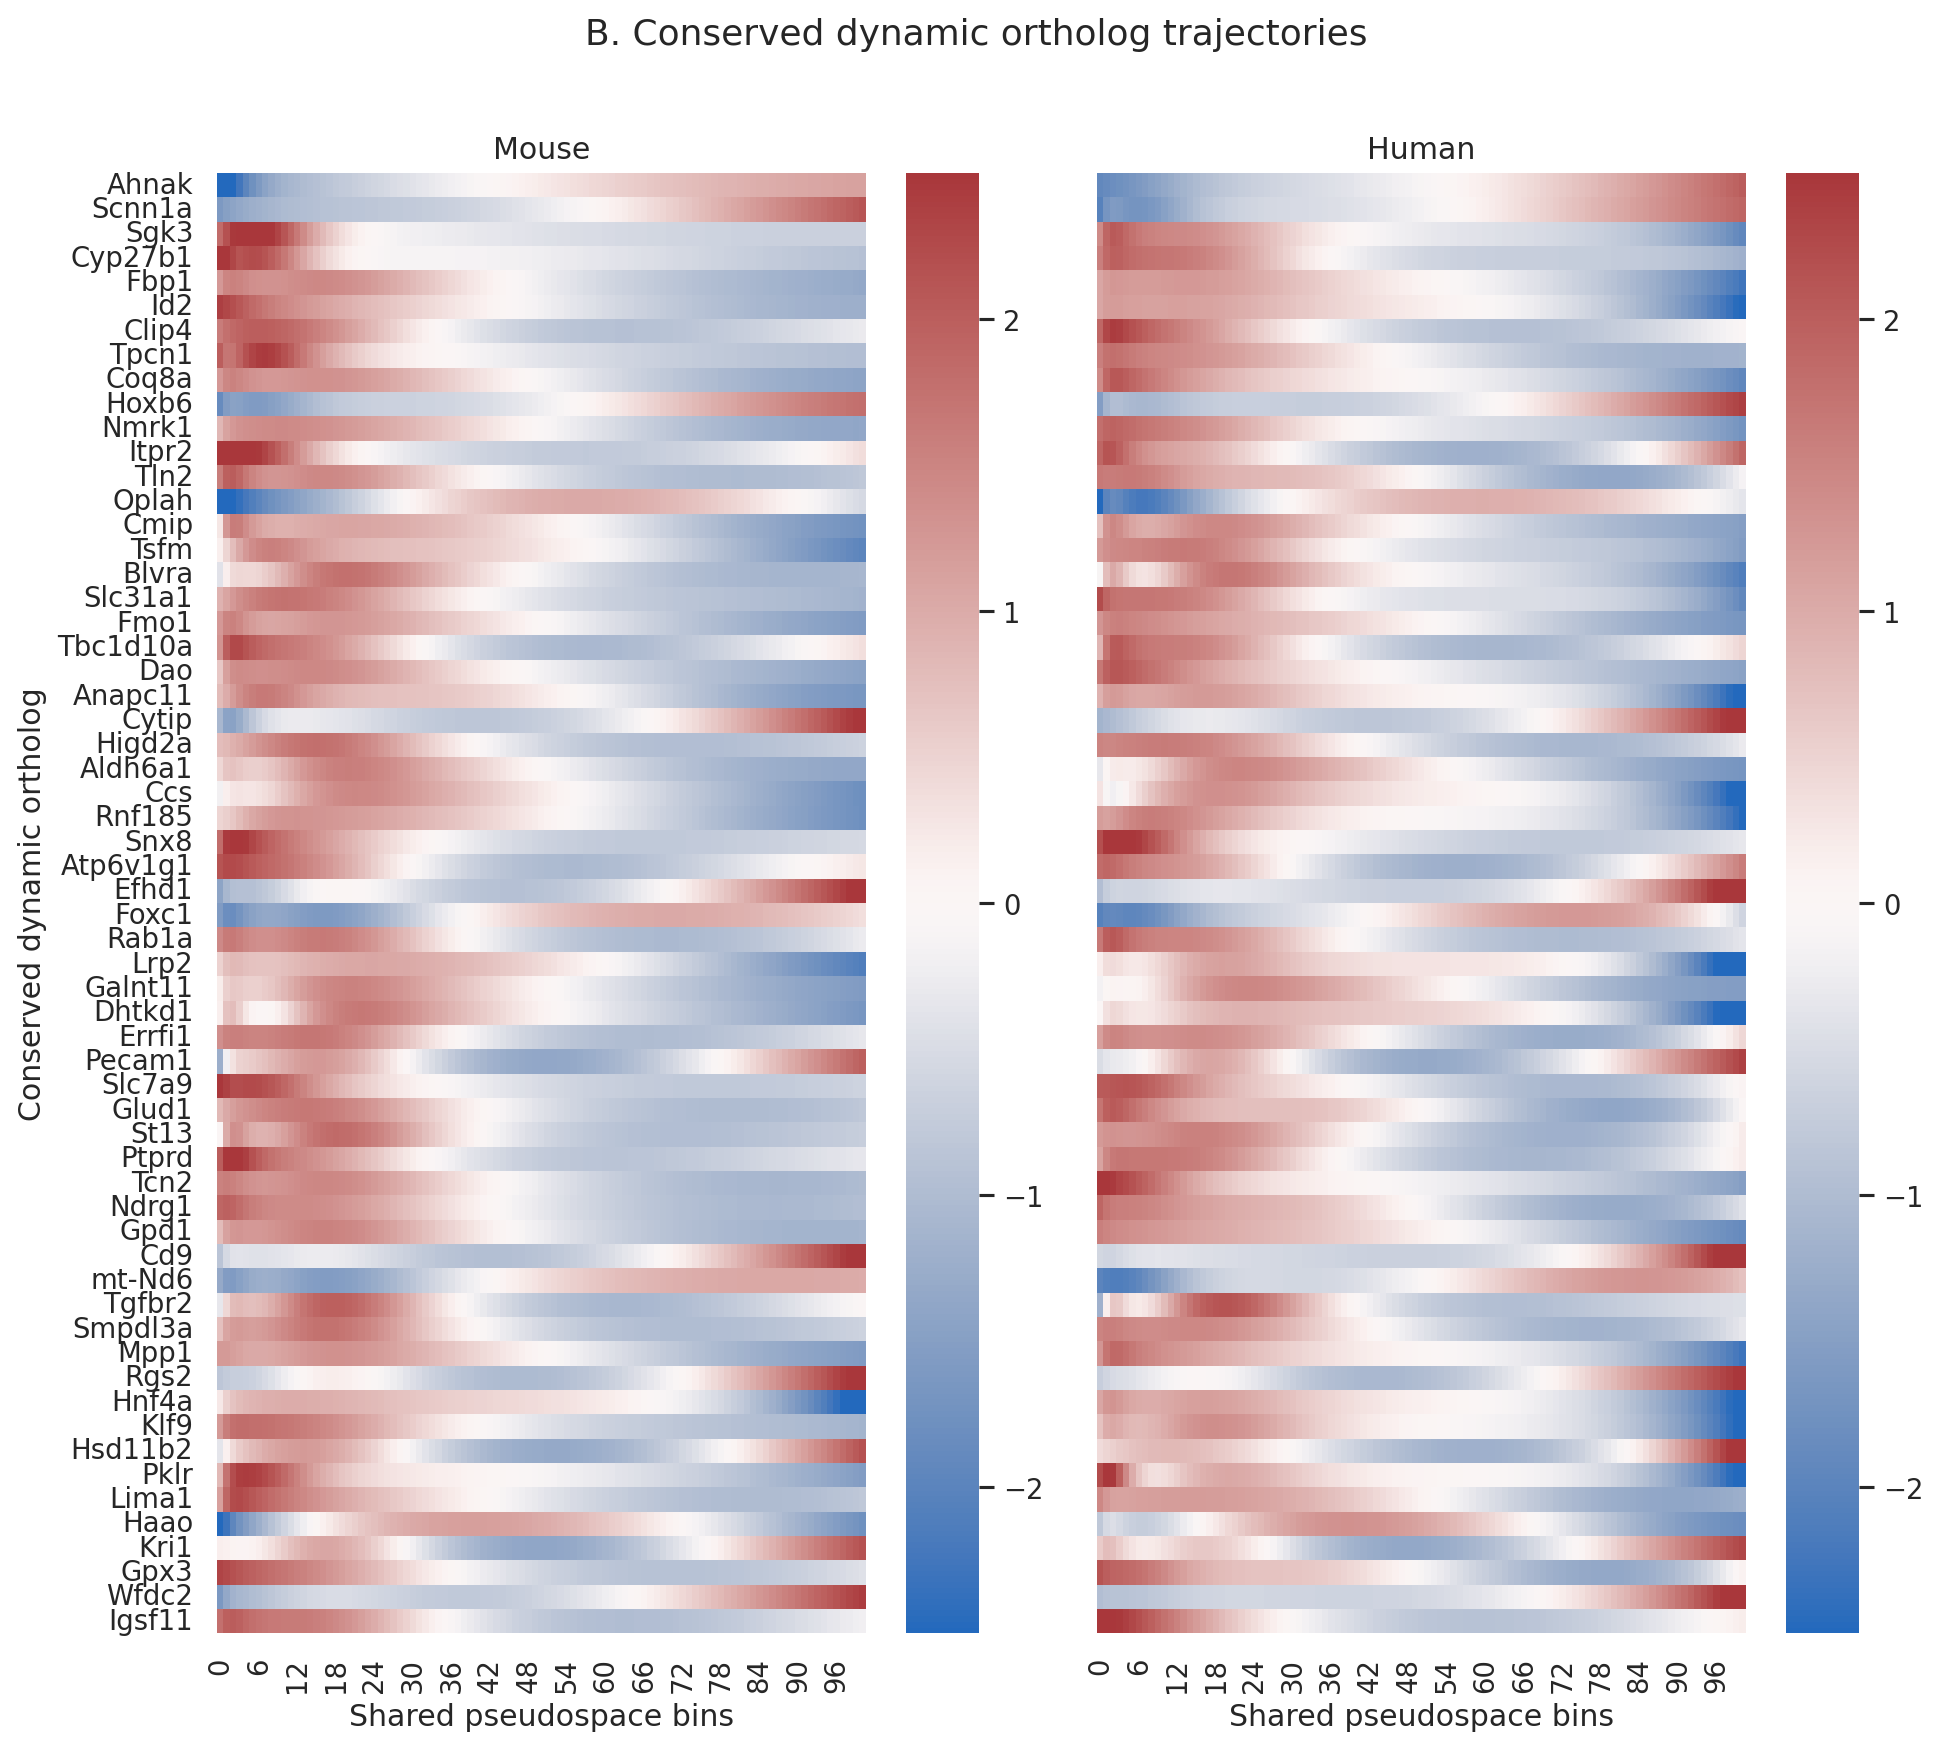

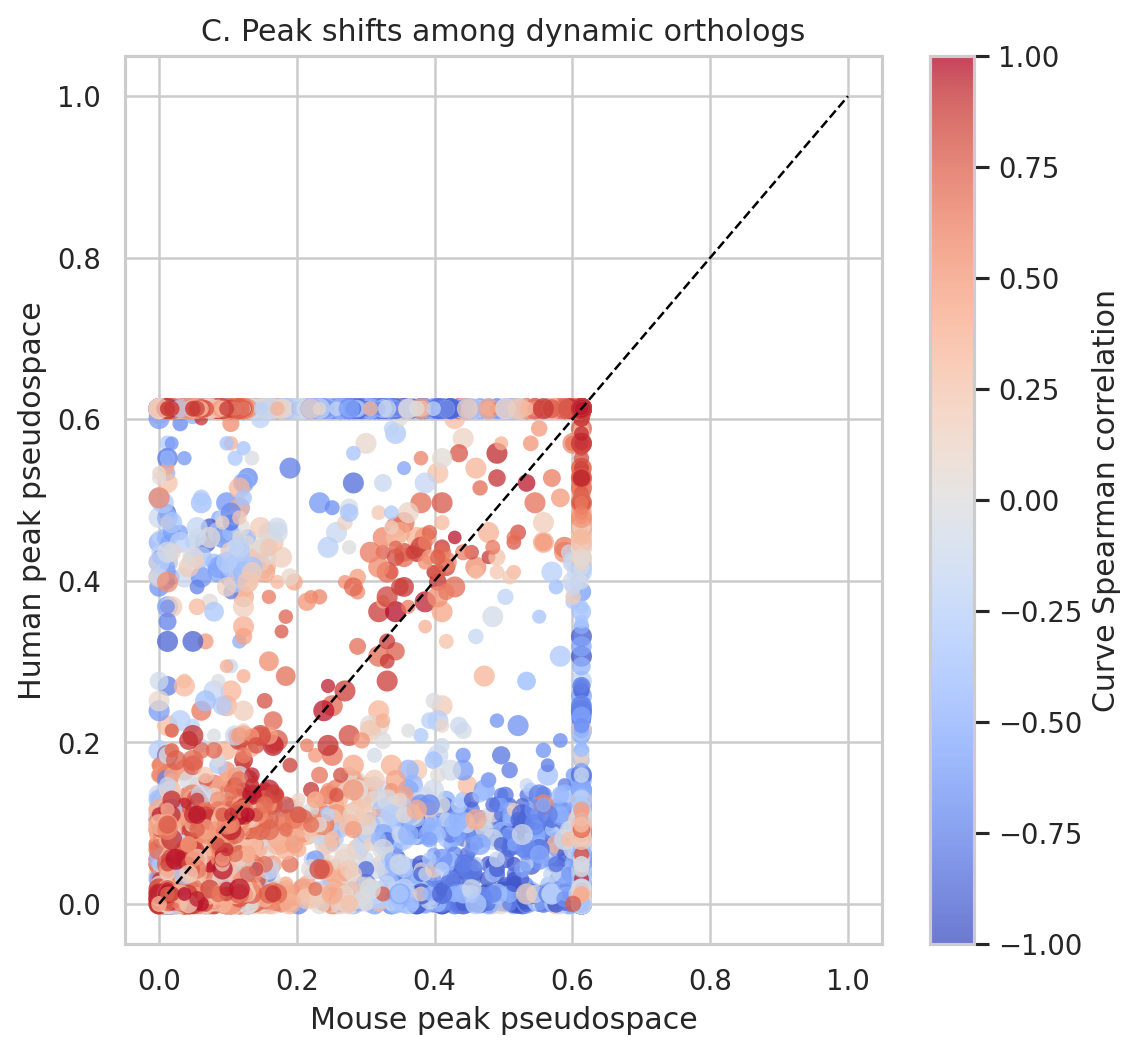

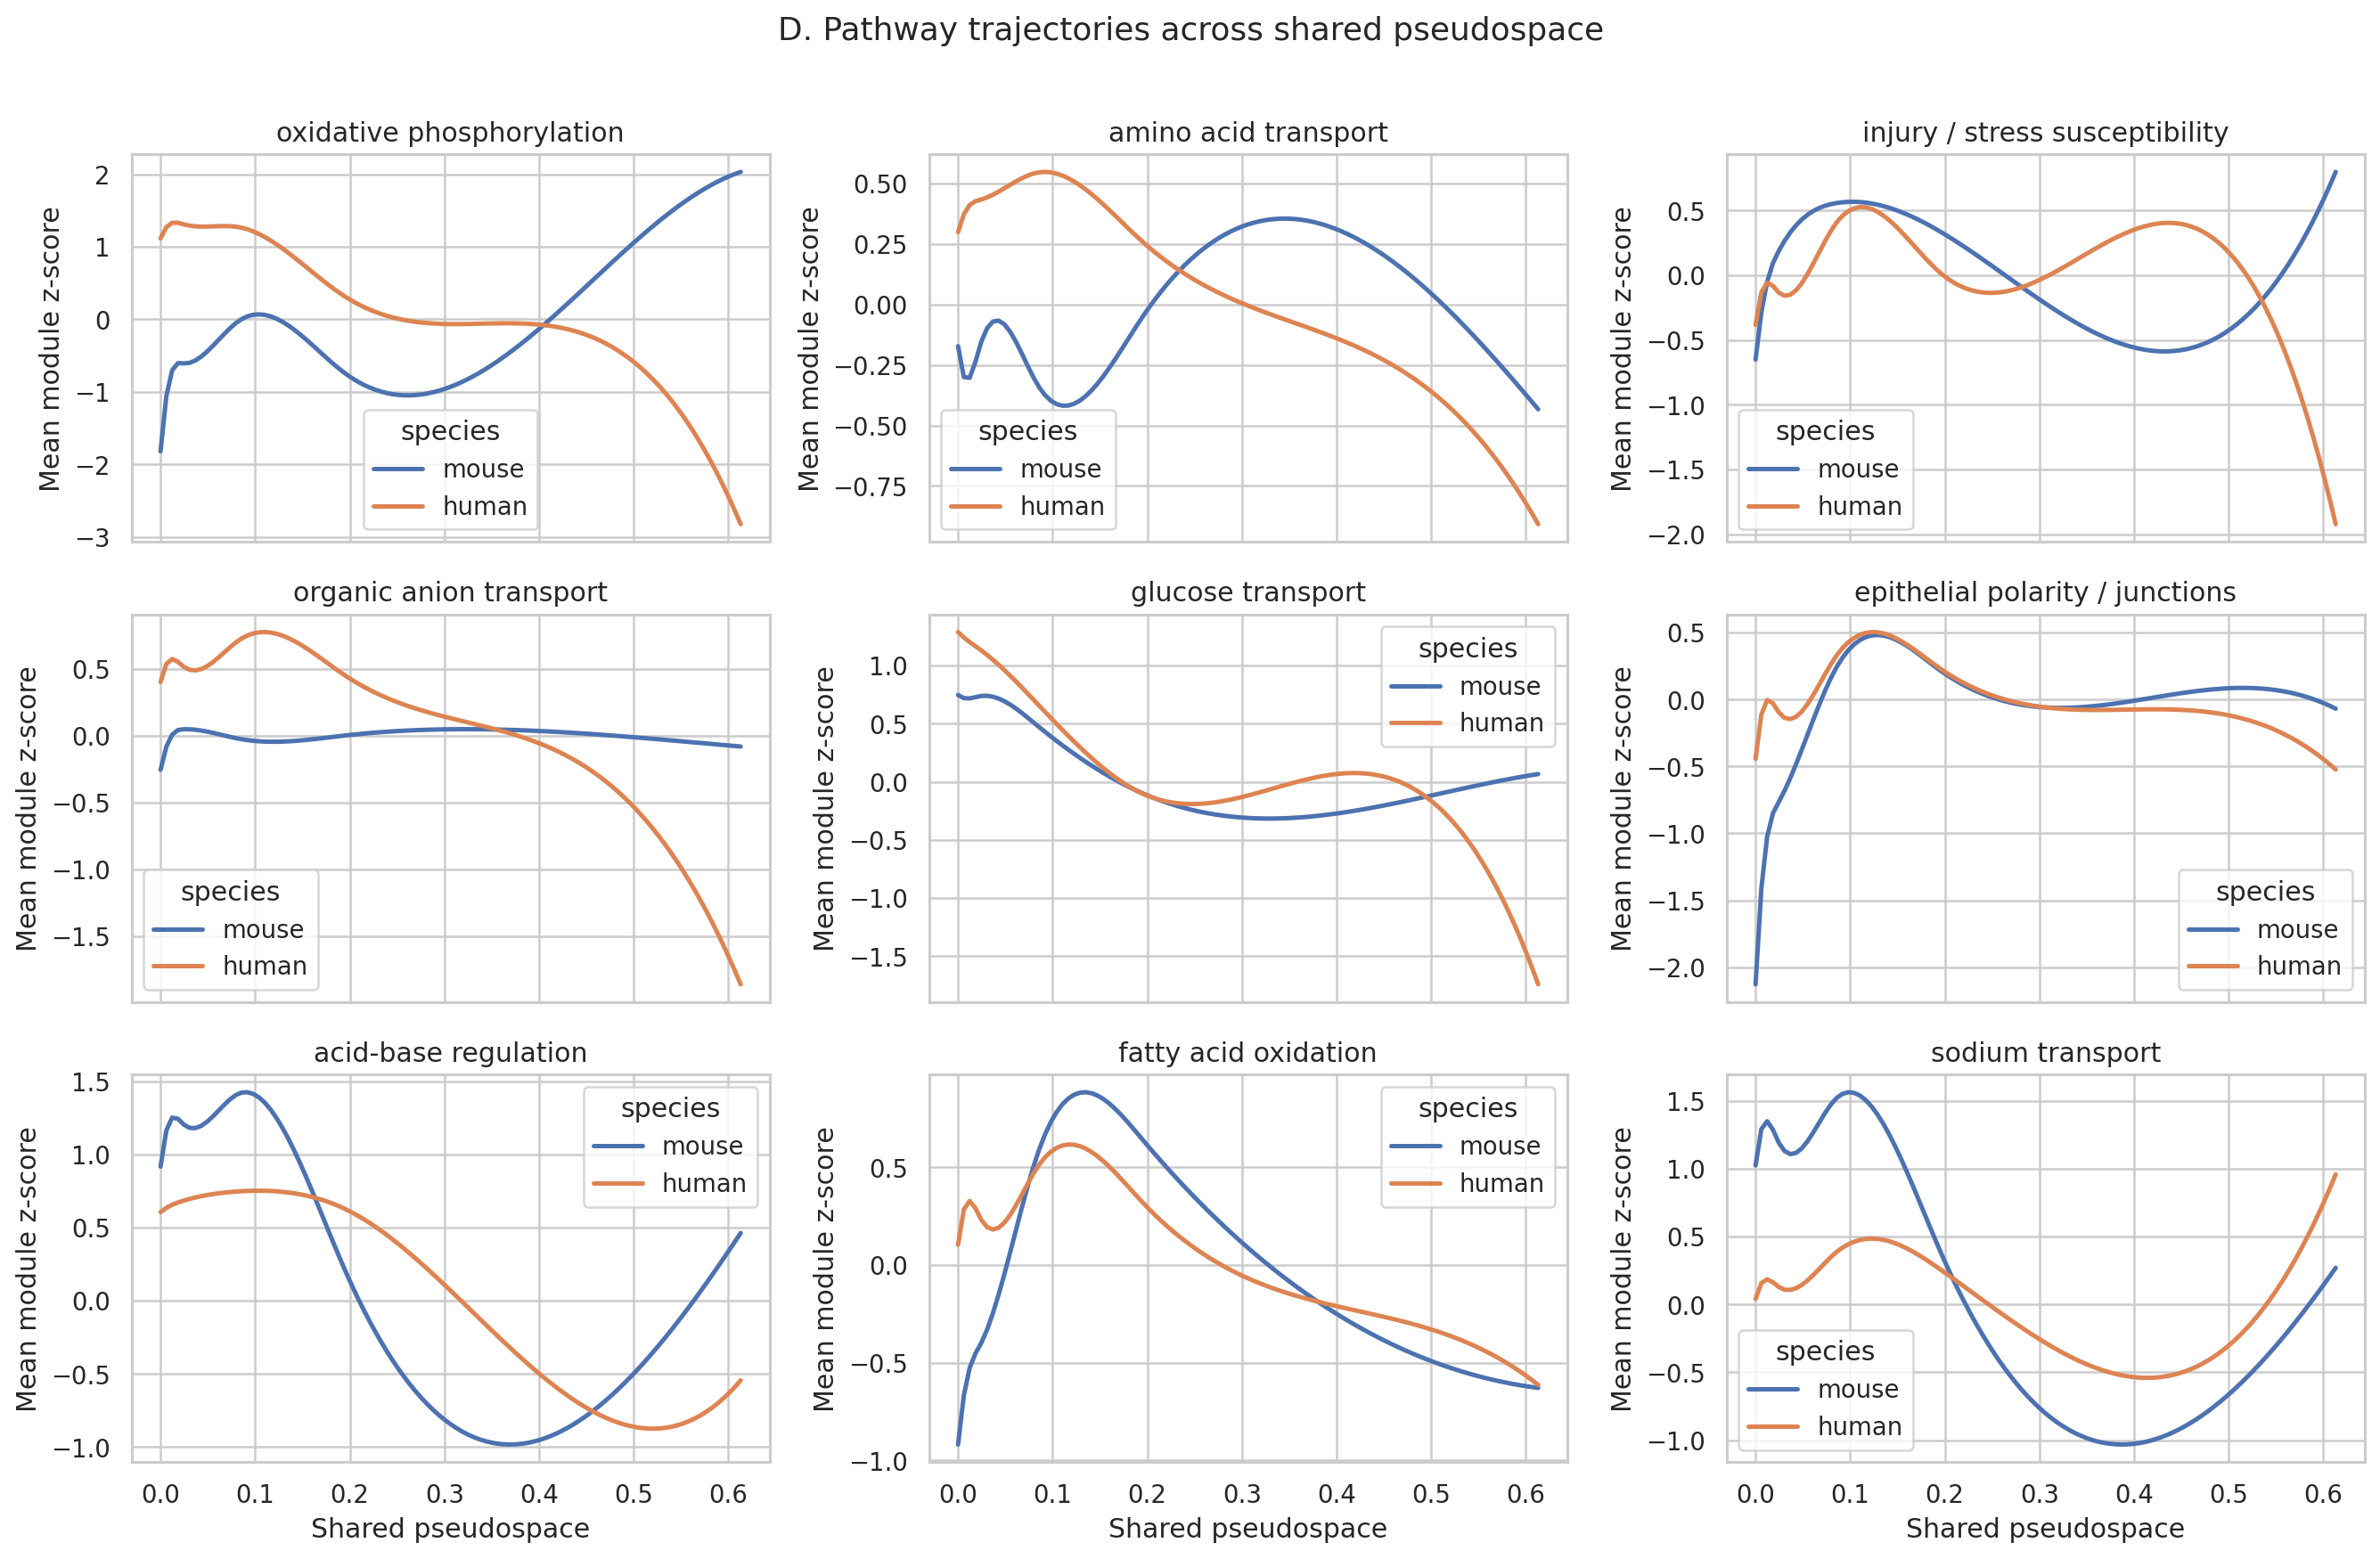

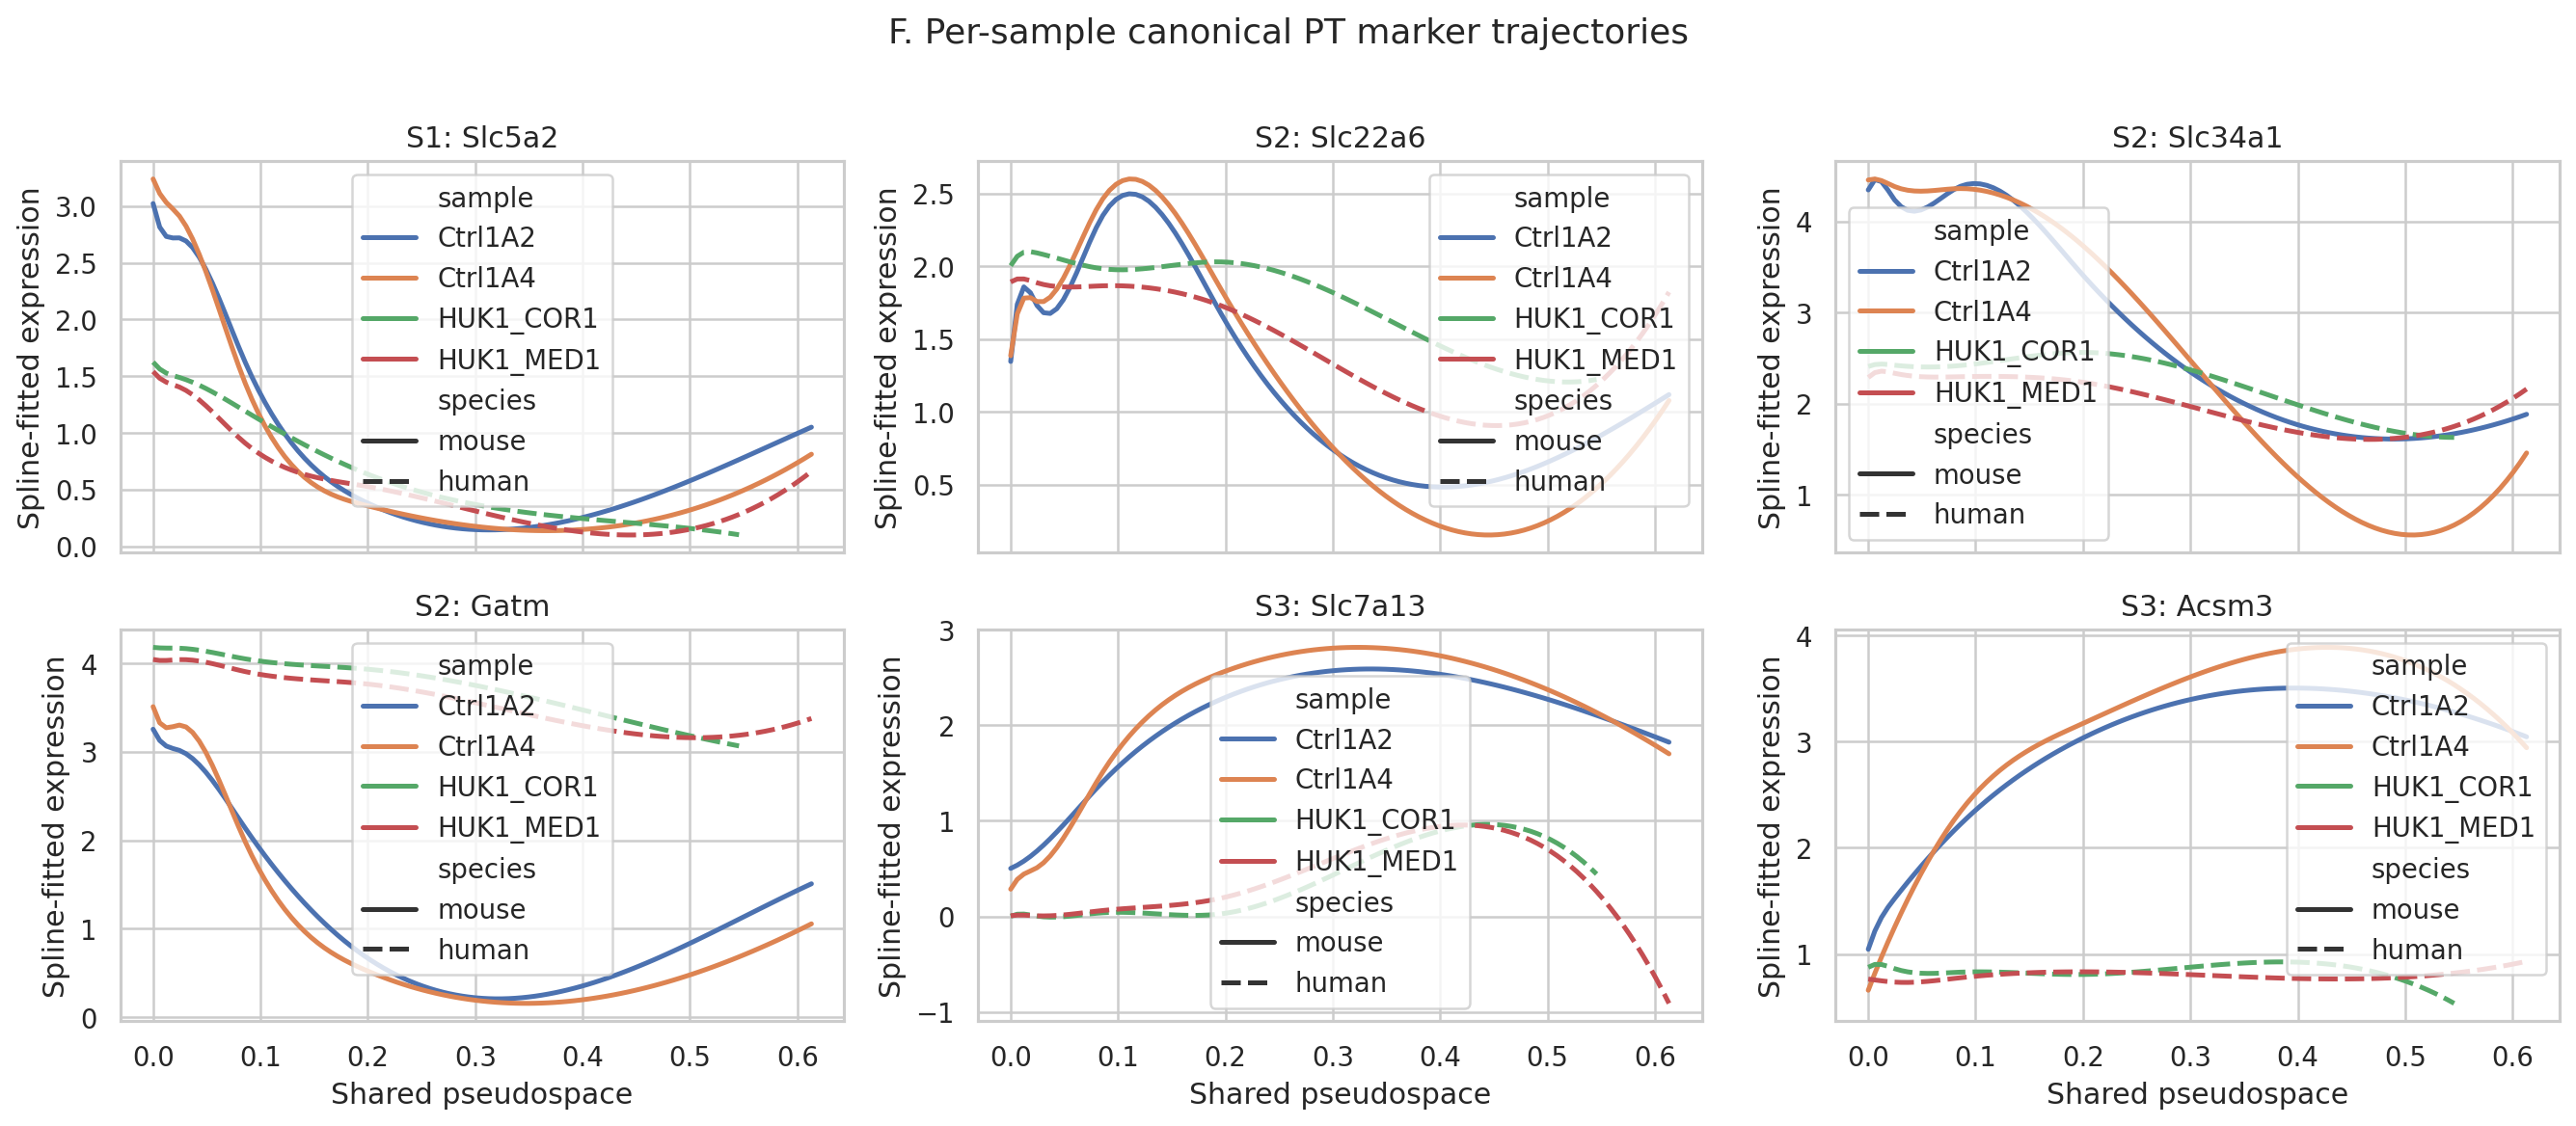

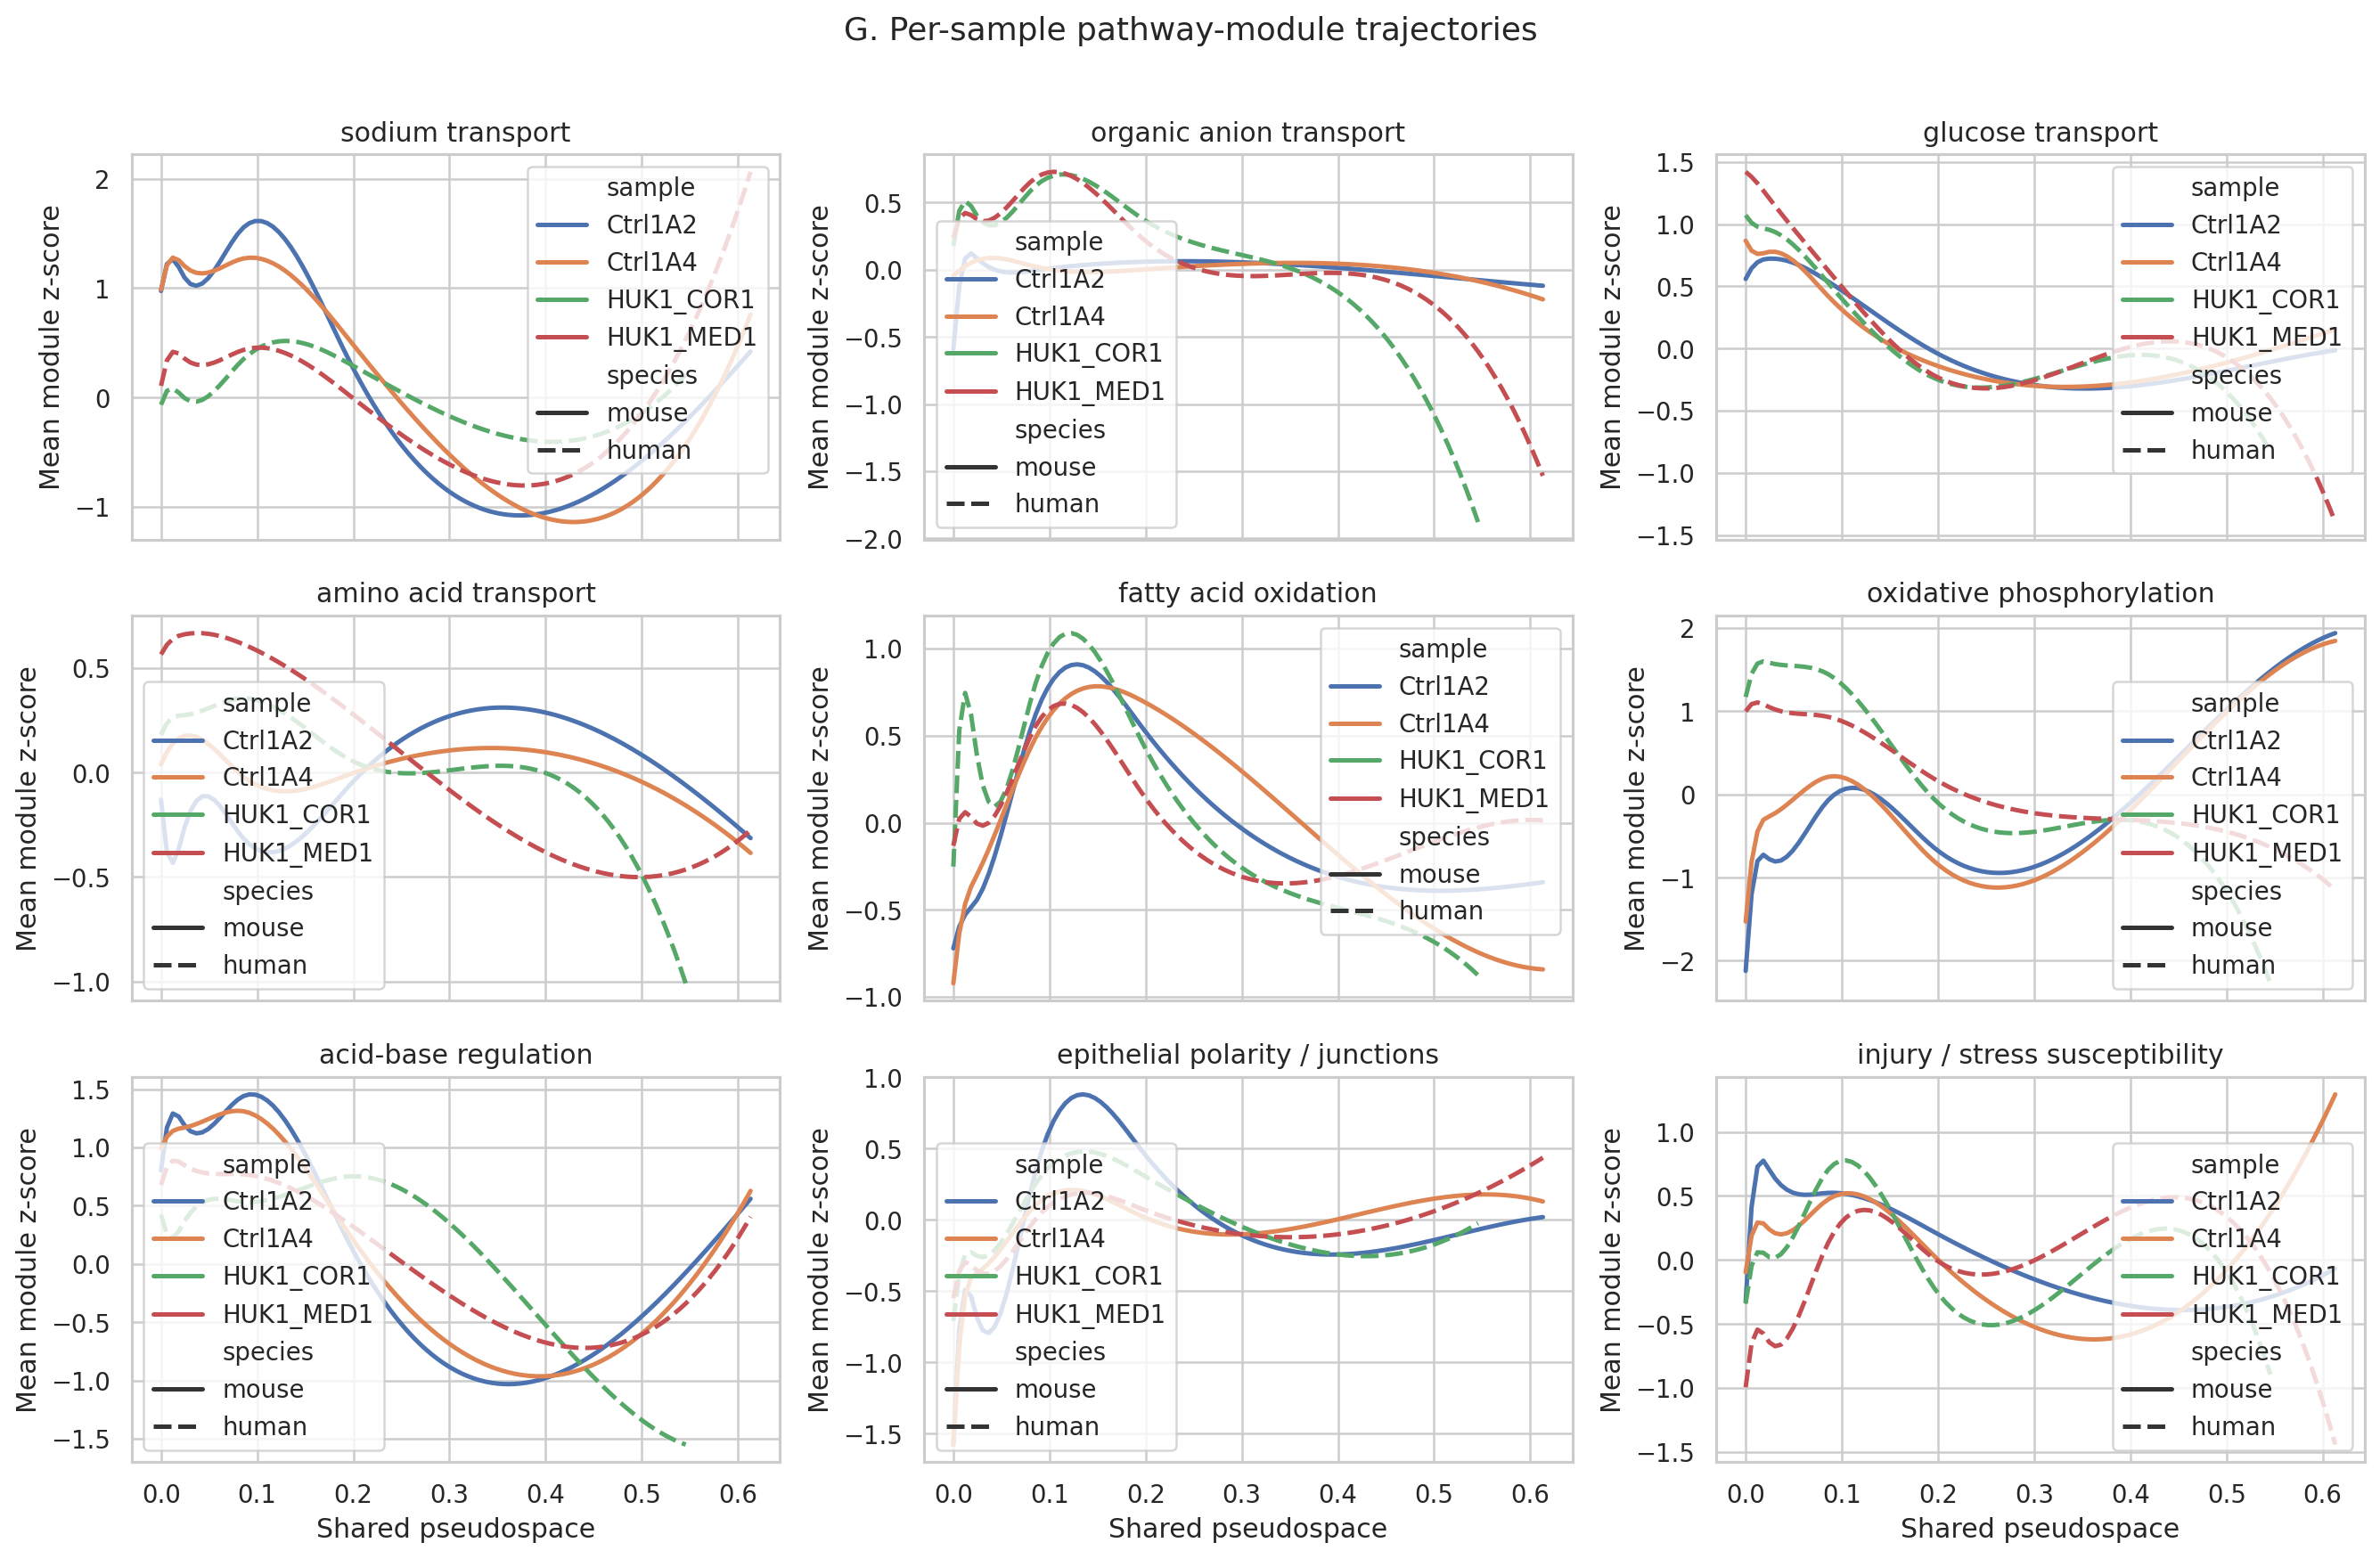

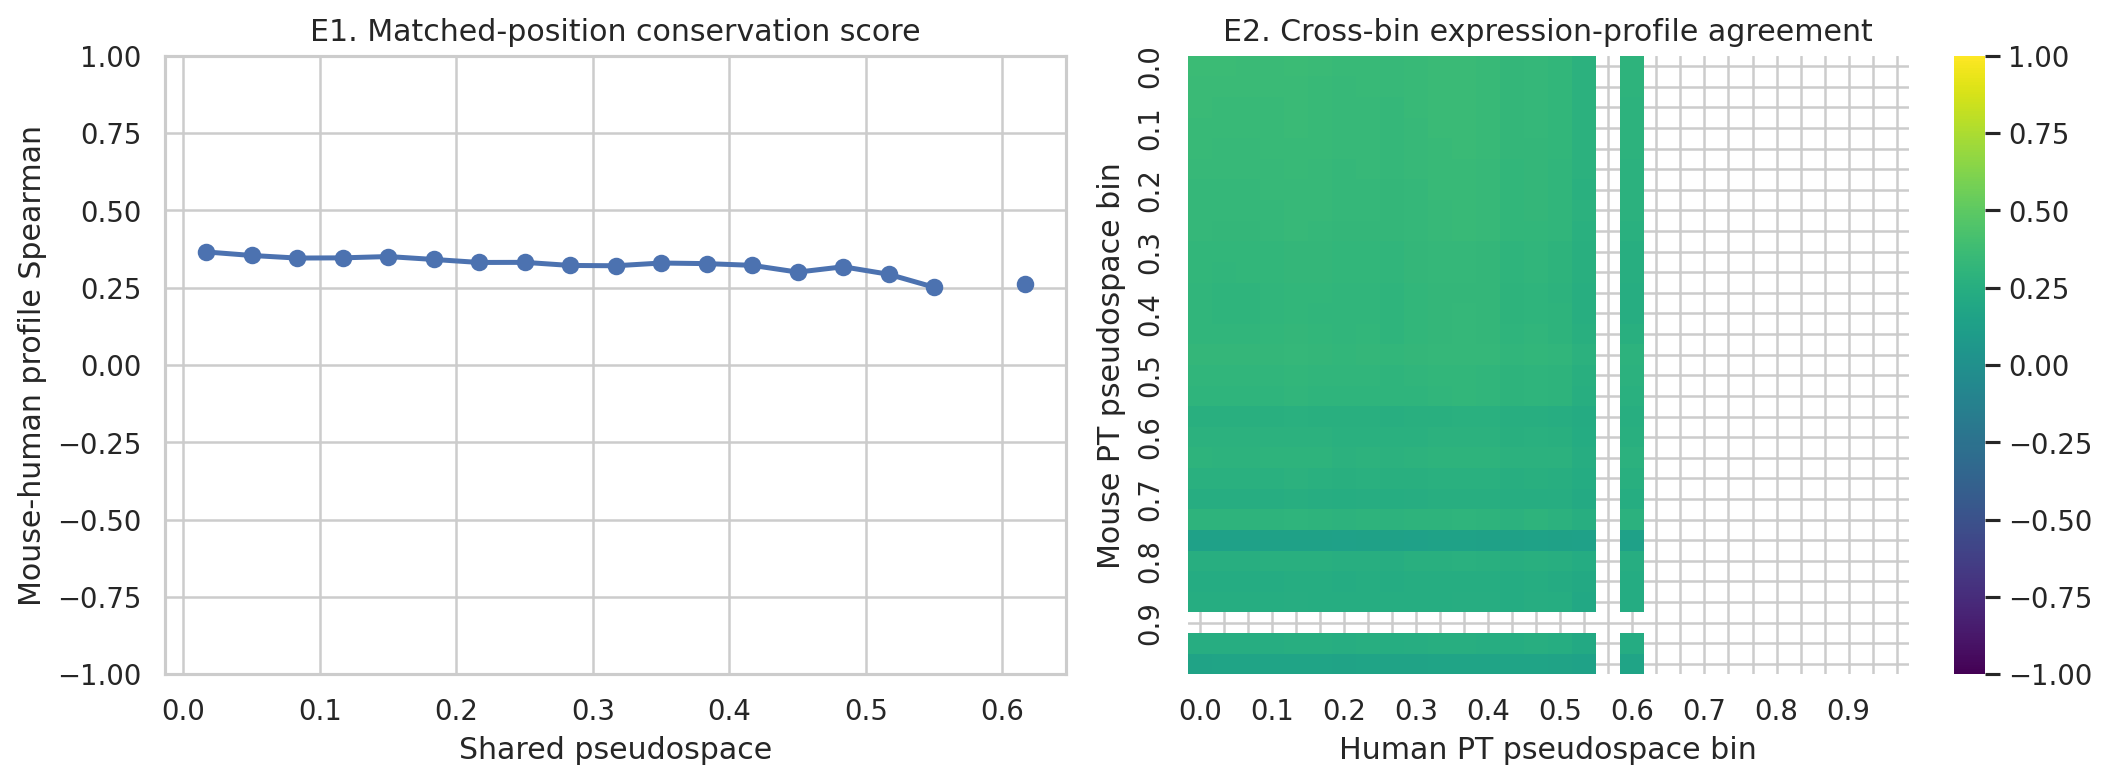

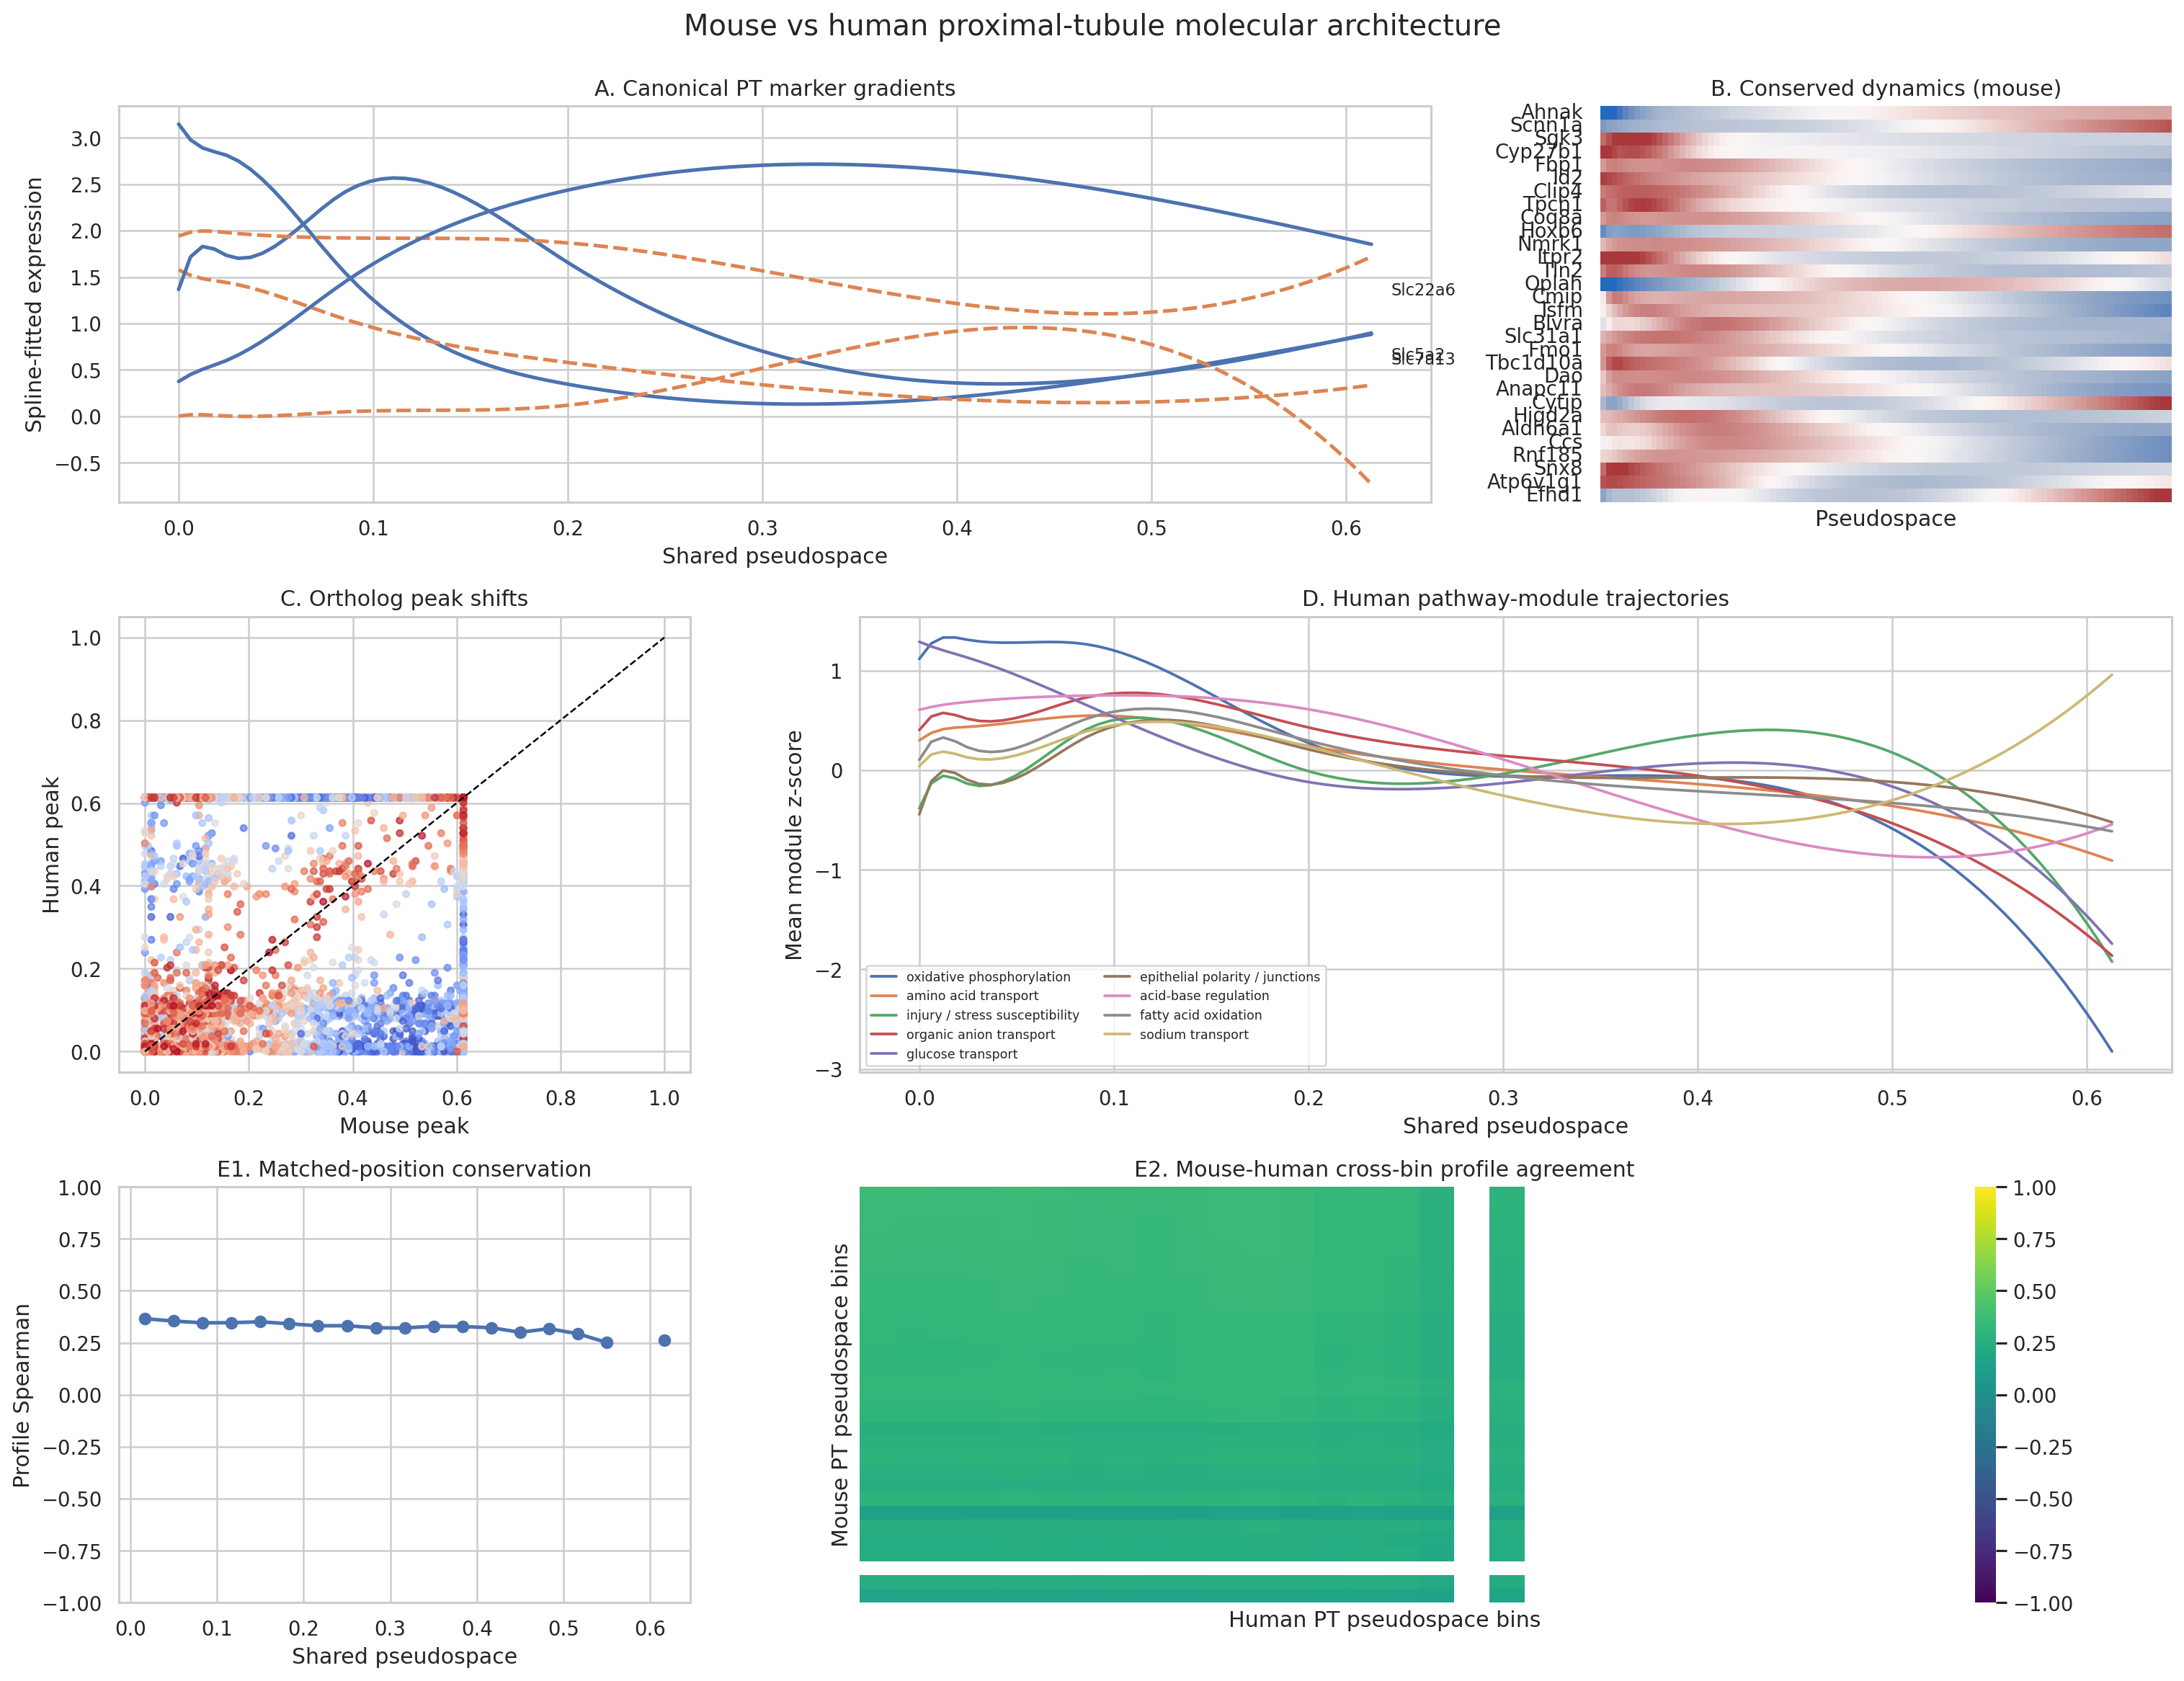


Segment-wise conservation score:
 pseudospace  mouse_human_profile_spearman
    0.016667                      0.365695
    0.050000                      0.354306
    0.083333                      0.345906
    0.116667                      0.346593
    0.150000                      0.350793
    0.183333                      0.341407
    0.216667                      0.331677
    0.250000                      0.332040
    0.283333                      0.322020
    0.316667                      0.321013
    0.350000                      0.329826
    0.383333                      0.327930
    0.416667                      0.322356
    0.450000                      0.300421
    0.483333                      0.317727
    0.516667                      0.293454
    0.550000                      0.251440
    0.583333                           NaN
    0.616667                      0.260685
    0.650000                           NaN
    0.683333                           NaN
    0.716667        

In [7]:
# Correlate mouse and human binned profiles using genes dynamic in at least one species.
dynamic_any = mouse['dynamic'] | human['dynamic']
if dynamic_any.sum() < 20:
    dynamic_any = np.ones(len(genes), dtype=bool)
mouse_bins = mouse['binned_means'][dynamic_any]
human_bins = human['binned_means'][dynamic_any]
bin_centers = mouse['centers']
conservation_matrix = np.full((CONFIG['n_bins'], CONFIG['n_bins']), np.nan)
for i in range(CONFIG['n_bins']):
    for j in range(CONFIG['n_bins']):
        valid = np.isfinite(mouse_bins[:, i]) & np.isfinite(human_bins[:, j])
        if valid.sum() >= 20:
            conservation_matrix[i, j] = safe_spearman(mouse_bins[valid, i], human_bins[valid, j])
diagonal_conservation = np.diag(conservation_matrix)
conservation_score = pd.DataFrame({
    'pseudospace': bin_centers,
    'mouse_human_profile_spearman': diagonal_conservation,
})
conservation_score.to_csv(OUTPUT_DIR / 'segmentwise_conservation_score.csv', index=False)
pd.DataFrame(
    conservation_matrix, index=bin_centers, columns=bin_centers
).to_csv(OUTPUT_DIR / 'cross_species_bin_correlation_matrix.csv')

# Select conserved dynamic genes for the paired heatmap, prioritizing high shape correlation.
both_dynamic = mouse['dynamic'] & human['dynamic']
heatmap_order = np.where(both_dynamic)[0]
if heatmap_order.size == 0:
    heatmap_order = np.where(dynamic_any)[0]
heatmap_rank_values = np.nan_to_num(curve_corr[heatmap_order], nan=-np.inf)
heatmap_order = heatmap_order[np.argsort(heatmap_rank_values)[::-1]]
heatmap_order = heatmap_order[:CONFIG['heatmap_genes']]
mouse_heat = zscore_rows(mouse['curves'][heatmap_order])
human_heat = zscore_rows(human['curves'][heatmap_order])
heatmap_genes = genes[heatmap_order]
heatmap_table = pd.concat([
    pd.DataFrame(mouse_heat, index=heatmap_genes, columns=[f'{x:.2f}' for x in grid]).assign(species='mouse'),
    pd.DataFrame(human_heat, index=heatmap_genes, columns=[f'{x:.2f}' for x in grid]).assign(species='human'),
])
heatmap_table.to_csv(OUTPUT_DIR / 'conserved_dynamic_heatmap_values.csv')

# Figure A: canonical marker-gradient validation.
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)
for ax, group in zip(axes, MARKER_GROUPS):
    subset = marker_curves.loc[marker_curves['marker_group'].eq(group)]
    sns.lineplot(
        data=subset, x='pseudospace', y='fitted_expression', hue='gene',
        style='species', ax=ax, linewidth=2,
    )
    ax.set_title(f'{group} markers')
    ax.set_xlabel('Shared pseudospace')
axes[0].set_ylabel('Spline-fitted log-normalized expression')
fig.suptitle('A. Conserved PT marker gradients in healthy mouse and human tubules', y=1.03)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'A_canonical_marker_gradients.png', bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(OUTPUT_DIR / 'A_canonical_marker_gradients.png')))

# Figure B: paired conserved-dynamic heatmaps.
fig, axes = plt.subplots(1, 2, figsize=(11, max(5, 0.16 * len(heatmap_genes))), sharey=True)
for ax, values, title in zip(axes, [mouse_heat, human_heat], ['Mouse', 'Human']):
    sns.heatmap(values, cmap='vlag', center=0, vmin=-2.5, vmax=2.5, yticklabels=heatmap_genes, ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Shared pseudospace bins')
axes[0].set_ylabel('Conserved dynamic ortholog')
fig.suptitle('B. Conserved dynamic ortholog trajectories', y=1.01)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'B_conserved_dynamic_ortholog_heatmap.png', bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(OUTPUT_DIR / 'B_conserved_dynamic_ortholog_heatmap.png')))

# Figure C: peak-shift scatter.
plot_stats = ortholog_stats.loc[ortholog_stats['mouse_dynamic'] | ortholog_stats['human_dynamic']].copy()
fig, ax = plt.subplots(figsize=(6.5, 6))
points = ax.scatter(
    plot_stats['mouse_peak_pseudospace'], plot_stats['human_peak_pseudospace'],
    c=plot_stats['curve_spearman'], s=16 + 55 * np.clip(plot_stats['amplitude_ratio'], 1, 4) / 4,
    cmap='coolwarm', vmin=-1, vmax=1, alpha=0.75, edgecolor='none',
)
ax.plot([0, 1], [0, 1], color='black', linestyle='--', linewidth=1)
ax.set(xlabel='Mouse peak pseudospace', ylabel='Human peak pseudospace',
       title='C. Peak shifts among dynamic orthologs')
fig.colorbar(points, ax=ax, label='Curve Spearman correlation')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'C_peak_shift_scatter.png', bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(OUTPUT_DIR / 'C_peak_shift_scatter.png')))

# Figure D: pathway-module trajectories.
modules = module_summary['module'].tolist()
ncols = 3
nrows = int(np.ceil(len(modules) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.2 * nrows), sharex=True)
axes = np.atleast_1d(axes).ravel()
for ax, module in zip(axes, modules):
    subset = module_curves.loc[module_curves['module'].eq(module)]
    sns.lineplot(data=subset, x='pseudospace', y='module_zscore', hue='species', ax=ax, linewidth=2)
    ax.set_title(module)
    ax.set_xlabel('Shared pseudospace')
    ax.set_ylabel('Mean module z-score')
for ax in axes[len(modules):]:
    ax.axis('off')
fig.suptitle('D. Pathway trajectories across shared pseudospace', y=1.01)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'D_pathway_module_trajectories.png', bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(OUTPUT_DIR / 'D_pathway_module_trajectories.png')))

# Figure F: sample-specific canonical-marker trajectories.
available_markers = sample_marker_curves[['marker_group', 'gene']].drop_duplicates()
ncols = 3
nrows = int(np.ceil(len(available_markers) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.2 * nrows), sharex=True)
axes = np.atleast_1d(axes).ravel()
for ax, (_, marker) in zip(axes, available_markers.iterrows()):
    subset = sample_marker_curves.loc[sample_marker_curves['gene'].eq(marker['gene'])]
    sns.lineplot(
        data=subset, x='pseudospace', y='fitted_expression', hue='sample',
        style='species', ax=ax, linewidth=2,
    )
    ax.set_title(f"{marker['marker_group']}: {marker['gene']}")
    ax.set_xlabel('Shared pseudospace')
    ax.set_ylabel('Spline-fitted expression')
for ax in axes[len(available_markers):]:
    ax.axis('off')
fig.suptitle('F. Per-sample canonical PT marker trajectories', y=1.01)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'F_per_sample_marker_curves.png', bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(OUTPUT_DIR / 'F_per_sample_marker_curves.png')))

# Figure G: sample-specific pathway-module trajectories.
available_modules = sample_module_curves['module'].drop_duplicates().tolist()
nrows = int(np.ceil(len(available_modules) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 3.2 * nrows), sharex=True)
axes = np.atleast_1d(axes).ravel()
for ax, module in zip(axes, available_modules):
    subset = sample_module_curves.loc[sample_module_curves['module'].eq(module)]
    sns.lineplot(
        data=subset, x='pseudospace', y='module_zscore', hue='sample',
        style='species', ax=ax, linewidth=2,
    )
    ax.set_title(module)
    ax.set_xlabel('Shared pseudospace')
    ax.set_ylabel('Mean module z-score')
for ax in axes[len(available_modules):]:
    ax.axis('off')
fig.suptitle('G. Per-sample pathway-module trajectories', y=1.01)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'G_per_sample_module_curves.png', bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(OUTPUT_DIR / 'G_per_sample_module_curves.png')))

# Figure E: segment-wise conservation and cross-bin agreement.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(bin_centers, diagonal_conservation, marker='o', linewidth=2)
axes[0].set(xlabel='Shared pseudospace', ylabel='Mouse-human profile Spearman',
            title='E1. Matched-position conservation score', ylim=(-1, 1))
sns.heatmap(
    conservation_matrix, cmap='viridis', vmin=-1, vmax=1,
    xticklabels=[f'{x:.1f}' if i % 3 == 0 else '' for i, x in enumerate(bin_centers)],
    yticklabels=[f'{x:.1f}' if i % 3 == 0 else '' for i, x in enumerate(bin_centers)],
    ax=axes[1],
)
axes[1].set(xlabel='Human PT pseudospace bin', ylabel='Mouse PT pseudospace bin',
            title='E2. Cross-bin expression-profile agreement')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'E_segmentwise_conservation.png', bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(OUTPUT_DIR / 'E_segmentwise_conservation.png')))

# Combined manuscript-oriented overview.
fig = plt.figure(figsize=(17, 13))
gs = fig.add_gridspec(3, 3, height_ratios=[1, 1.15, 1.05])
ax_a = fig.add_subplot(gs[0, :2])
for gene in ['Slc5a2', 'Slc22a6', 'Slc7a13']:
    subset = marker_curves.loc[marker_curves['gene'].eq(gene)]
    sns.lineplot(data=subset, x='pseudospace', y='fitted_expression', hue='species',
                 style='species', ax=ax_a, linewidth=2, legend=False)
    final = subset.sort_values('pseudospace').groupby('species', observed=True).tail(1)
    if not final.empty:
        ax_a.text(final['pseudospace'].max() + 0.01, final['fitted_expression'].mean(), gene, fontsize=9)
ax_a.set(title='A. Canonical PT marker gradients', xlabel='Shared pseudospace',
         ylabel='Spline-fitted expression')
ax_b = fig.add_subplot(gs[0, 2])
sns.heatmap(mouse_heat[:30], cmap='vlag', center=0, vmin=-2.5, vmax=2.5, cbar=False, ax=ax_b,
            yticklabels=heatmap_genes[:30], xticklabels=False)
ax_b.set(title='B. Conserved dynamics (mouse)', xlabel='Pseudospace', ylabel='')
ax_c = fig.add_subplot(gs[1, 0])
ax_c.scatter(plot_stats['mouse_peak_pseudospace'], plot_stats['human_peak_pseudospace'],
             c=plot_stats['curve_spearman'], cmap='coolwarm', vmin=-1, vmax=1, s=12, alpha=0.7)
ax_c.plot([0, 1], [0, 1], '--', color='black', linewidth=1)
ax_c.set(title='C. Ortholog peak shifts', xlabel='Mouse peak', ylabel='Human peak')
ax_d = fig.add_subplot(gs[1, 1:])
for module in modules:
    subset = module_curves.loc[module_curves['module'].eq(module) & module_curves['species'].eq('human')]
    ax_d.plot(subset['pseudospace'], subset['module_zscore'], linewidth=1.5, label=module)
ax_d.set(title='D. Human pathway-module trajectories', xlabel='Shared pseudospace',
         ylabel='Mean module z-score')
ax_d.legend(fontsize=7, ncol=2)
ax_e1 = fig.add_subplot(gs[2, 0])
ax_e1.plot(bin_centers, diagonal_conservation, marker='o', linewidth=2)
ax_e1.set(title='E1. Matched-position conservation', xlabel='Shared pseudospace',
          ylabel='Profile Spearman', ylim=(-1, 1))
ax_e2 = fig.add_subplot(gs[2, 1:])
sns.heatmap(conservation_matrix, cmap='viridis', vmin=-1, vmax=1, ax=ax_e2,
            xticklabels=False, yticklabels=False)
ax_e2.set(title='E2. Mouse-human cross-bin profile agreement',
          xlabel='Human PT pseudospace bins', ylabel='Mouse PT pseudospace bins')
fig.suptitle('Mouse vs human proximal-tubule molecular architecture', fontsize=16, y=0.995)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'mouse_vs_human_PT_summary_figure.png', bbox_inches='tight')
plt.close(fig)
display(Image(filename=str(OUTPUT_DIR / 'mouse_vs_human_PT_summary_figure.png')))

print('\nSegment-wise conservation score:')
print(conservation_score.to_string(index=False))
print(f'\nSaved tables and figures to: {OUTPUT_DIR.relative_to(PROJECT_DIR)}')


## Interpretation notes

- `A_canonical_marker_gradients.png` validates whether the shared upstream DPT coordinate
  preserves the expected S1-S3 organization in both species.
- `ortholog_trajectory_classification.csv` provides the requested ortholog-level
  categories, curve correlations, peak positions, amplitudes, and spline-interaction
  statistics.
- `species_pattern_interaction_hits.csv` contains genes whose smooth PT patterns differ
  significantly by species.
- `pathway_module_summary.csv` summarizes pathway-level curve correlation, peak shifts,
  and area-under-curve differences.
- `segmentwise_conservation_score.csv` and `E_segmentwise_conservation.png` identify the
  PT positions with strongest mouse-human profile conservation.
- `F_per_sample_marker_curves.png` and `G_per_sample_module_curves.png` show whether
  marker and module trajectories are reproducible across the individual samples.

Interpret species-interaction hits as healthy mouse-vs-human differences in this dataset.
The human samples are from one donor and the mouse controls are from two samples, so
biological replication is limited.

- `functional_enrichment_all_terms.csv` and
  `functional_enrichment_significant_terms.csv` contain the gene-list enrichment bridge
  from ortholog-level spline hits to pathway trajectory modeling.
- `prioritized_enriched_pathways_for_spline_modeling.csv` lists the significant enriched
  GO/pathway terms selected for pathway-score spline modeling.
- `pathway_trajectory_classification.csv` contains pathway-level permutation dynamics,
  species interactions, curve correlations, peak shifts, and conservation classes for
  those prioritized enriched terms.
- `H_pathway_library_summary.png`, `I_top_divergent_pathway_trajectories.png`, and
  `J_top_pathway_per_sample_curves.png` summarize pathway-level results and sample
  sensitivity.
